In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded NFHS-5 key indicators file
file_path = "/content/drive/MyDrive/Colab Notebooks/NFHS-5/NFHS5_key_indicators.xlsx"
nfhs_df = pd.read_excel(file_path)
file_path1 = "/content/drive/MyDrive/Colab Notebooks/NFHS-5/RS_Session_266_AU_1677_B_2.csv"
sgdp_df = pd.read_csv(file_path1)
# Display the first few rows of the DataFrame
print(sgdp_df.head())

   Sl. No.              State  Per Capita GSDP - 2019-2020  \
0        1     Andhra Pradesh                       179280   
1        2  Arunachal Pradesh                       198701   
2        3              Assam                       100501   
3        4              Bihar                        48263   
4        5        Chhatisgarh                       119066   

   Per Capita GSDP - 2020-2021  Per Capita GSDP - 2021-22  \
0                       188384                     219799   
1                       200035                     212372   
2                        97401                     116554   
3                        46412                      52144   
4                       120113                     138256   

   Per Capita GSDP - 2022-23  Per Capita GSDP - 2023-24  
0                     245582                   270295.0  
1                     225770                        NaN  
2                     134591                   158807.0  
3                      59244

In [ ]:
# Create a mapping dictionary for inconsistent state names
state_name_mapping = {
    'Chhattisgarh': 'Chhatisgarh', # Correct nfhs_df to match gdp_df
    'Maharastra': 'Maharashtra' # Correct nfhs_df to match gdp_df
}

# Apply the mapping to the 'States/UTs' column in nfhs_df
nfhs_df['States/UTs'] = nfhs_df['States/UTs'].replace(state_name_mapping)

# Display the updated unique states from nfhs_df to verify
print('Updated Unique States/UTs in nfhs_df after mapping:', sorted(list(nfhs_df['States/UTs'].unique())))

# 1. Keep only state-level (Total) rows from NFHS
nfhs_state = nfhs_df[nfhs_df["Area"] == "Total"].copy()

# 2. Clean state names in both datasets
nfhs_state["state_clean"] = (
    nfhs_state["States/UTs"]
    .str.strip()
    .str.replace("&", "and")
)

sgdp_df["state_clean"] = (
    sgdp_df["State"]
    .str.strip()
    .str.replace("&", "and")
)

# 3. Merge datasets
merged_df = nfhs_state.merge(
    sgdp_df.drop(columns=["Sl. No.", "State"]),
    on="state_clean",
    how="left"
)

# View result
merged_df


Updated Unique States/UTs in nfhs_df after mapping: ['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhatisgarh', 'Dadra and Nagar Haveli & Daman and Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'India', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'NCT of Delhi', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%),state_clean,Per Capita GSDP - 2019-2020,Per Capita GSDP - 2020-2021,Per Capita GSDP - 2021-22,Per Capita GSDP - 2022-23,Per Capita GSDP - 2023-24
0,India,Total,636699,724115,101839,71.8,26.5,1020.0,929,89.1,...,8.9,38.0,1.3,18.8,India,NaN,NaN,NaN,NaN,NaN
1,Andaman & Nicobar Islands,Total,2624,2397,367,83.5,20.8,963.0,914,97.4,...,31.3,58.7,5.0,39.1,Andaman and Nicobar Islands,NaN,NaN,NaN,NaN,NaN
2,Andhra Pradesh,Total,11346,10975,1558,65.6,22.2,1045.1,933.6,92.2,...,3.8,22.6,0.5,23.3,Andhra Pradesh,179280.0,188384.0,219799.0,245582.0,270295.0
3,Arunachal Pradesh,Total,18268,19765,2881,71.2,27.1,997.0,979,87.7,...,18.8,50.3,24.2,52.7,Arunachal Pradesh,198701.0,200035.0,212372.0,225770.0,NaN
4,Assam,Total,30119,34979,4973,78.2,28.3,1012.0,964,96.3,...,22.1,51.8,7.3,25.1,Assam,100501.0,97401.0,116554.0,134591.0,158807.0
5,Bihar,Total,35834,42483,4897,61.1,36.4,1090.0,908,75.6,...,5.0,48.8,0.4,15.5,Bihar,48263.0,46412.0,52144.0,59244.0,66828.0
6,Chandigarh,Total,761,746,104,86.7,23.3,917.0,838,97.6,...,0.6,12.1,0.3,18.6,Chandigarh,NaN,NaN,NaN,NaN,NaN
7,Chhatisgarh,Total,24550,28468,4174,69.3,25.4,1015.0,960,96.6,...,17.3,43.1,5.0,34.8,Chhatisgarh,119066.0,120113.0,138256.0,154609.0,166520.0
8,Dadra and Nagar Haveli & Daman and Diu,Total,2676,2713,427,74.4,25.4,827.0,817,98.1,...,2.9,38.6,1.1,27.8,Dadra and Nagar Haveli and Daman and Diu,NaN,NaN,NaN,NaN,NaN
9,Goa,Total,1856,2030,313,89.0,19.1,1027.0,838,100,...,2.6,18.2,5.5,36.9,Goa,485645.0,476900.0,519681.0,567344.0,NaN


In [ ]:
# # Create a mapping dictionary for inconsistent state names
# state_name_mapping = {
#     'Chhattisgarh': 'Chhatisgarh', # Correct nfhs_df to match gdp_df
#     'Maharastra': 'Maharashtra' # Correct nfhs_df to match gdp_df
# }

# # Apply the mapping to the 'States/UTs' column in nfhs_df
# nfhs_df['States/UTs'] = nfhs_df['States/UTs'].replace(state_name_mapping)

# # Display the updated unique states from nfhs_df to verify
# print('Updated Unique States/UTs in nfhs_df after mapping:', sorted(list(nfhs_df['States/UTs'].unique())))

# # Re-merge the DataFrames with the corrected state names
# merged = nfhs_df.merge(sgdp_df, how="left", left_on="States/UTs", right_on="State")

# # Display the first few rows of the re-merged DataFrame
# print('\nMerged DataFrame head after name standardization:')
# print(merged.head())

In [ ]:
sgdp_col = "Per Capita GSDP - 2020-2021"
df_clean = merged_df.dropna(subset=[sgdp_col]).copy()
df_clean.head(30)


,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%),state_clean,Per Capita GSDP - 2019-2020,Per Capita GSDP - 2020-2021,Per Capita GSDP - 2021-22,Per Capita GSDP - 2022-23,Per Capita GSDP - 2023-24
2,Andhra Pradesh,Total,11346,10975,1558,65.6,22.2,1045.1,933.6,92.2,...,3.8,22.6,0.5,23.3,Andhra Pradesh,179280.0,188384.0,219799.0,245582.0,270295.0
3,Arunachal Pradesh,Total,18268,19765,2881,71.2,27.1,997.0,979,87.7,...,18.8,50.3,24.2,52.7,Arunachal Pradesh,198701.0,200035.0,212372.0,225770.0,NaN
4,Assam,Total,30119,34979,4973,78.2,28.3,1012.0,964,96.3,...,22.1,51.8,7.3,25.1,Assam,100501.0,97401.0,116554.0,134591.0,158807.0
5,Bihar,Total,35834,42483,4897,61.1,36.4,1090.0,908,75.6,...,5.0,48.8,0.4,15.5,Bihar,48263.0,46412.0,52144.0,59244.0,66828.0
7,Chhatisgarh,Total,24550,28468,4174,69.3,25.4,1015.0,960,96.6,...,17.3,43.1,5.0,34.8,Chhatisgarh,119066.0,120113.0,138256.0,154609.0,166520.0
9,Goa,Total,1856,2030,313,89.0,19.1,1027.0,838,100,...,2.6,18.2,5.5,36.9,Goa,485645.0,476900.0,519681.0,567344.0,NaN
10,Gujarat,Total,29368,33343,5351,72.9,24.0,965.0,955,97.5,...,8.7,41.1,0.6,5.8,Gujarat,238978.0,232862.0,273290.0,309691.0,NaN
11,Haryana,Total,18229,21909,3224,73.8,25.3,926.0,893,95.1,...,2.5,29.1,0.3,16.1,Haryana,258006.0,251311.0,295325.0,329777.0,361993.0
12,Himachal Pradesh,Total,10698,10368,1477,81.0,21.8,1040.0,875,97.9,...,1.7,32.3,0.6,31.9,Himachal Pradesh,217229.0,205589.0,232180.0,257249.0,276943.0
14,Jharkhand,Total,22863,26495,3414,64.5,31.3,1050.0,899,73.5,...,8.4,47.4,6.1,35.0,Jharkhand,82276.0,77561.0,97035.0,106310.0,115960.0


In [ ]:
df_clean["SGDP_Category"] = pd.qcut(
    df_clean[sgdp_col],
    q=3,
    labels=["Low", "Moderate", "High"]
)
df_clean.groupby("SGDP_Category").size()


/tmp/ipython-input-3279633800.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("SGDP_Category").size()


,0
SGDP_Category,
Low,10
Moderate,8
High,10


In [ ]:
nfhs_cols = df_clean.select_dtypes(include=[np.number]).columns

nfhs_indicator_cols = [
    col for col in nfhs_cols if "GSDP" not in col
]

nfhs_data = df_clean[nfhs_indicator_cols]


In [ ]:
# missing data values
nfhs_data = nfhs_data.replace("*", np.nan)

corr_matrix = nfhs_data.corr()
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Indicator_1", "Indicator_2", "Correlation"]

### Sort by absolute correlation ###
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

corr_pairs_sorted = corr_pairs.sort_values(
    by="Abs_Correlation", ascending=False
)
# Example: drop survey-size variables
corr_pairs_sorted = corr_pairs_sorted[~corr_pairs_sorted["Indicator_1"].str.contains("Number of")]
corr_pairs_sorted = corr_pairs_sorted[~corr_pairs_sorted["Indicator_2"].str.contains("Number of")]
corr_pairs_sorted =  corr_pairs_sorted[(corr_pairs_sorted["Indicator_1"] != corr_pairs_sorted["Indicator_2"])]
# corr_pairs_sorted = corr_pairs_sorted[~corr_pairs_sorted["Indicator_1"].str.contains("Men") & ~corr_pairs_sorted["Indicator_2"].str.contains("Women")]
# corr_pairs_sorted = corr_pairs_sorted[~corr_pairs_sorted["Indicator_1"].str.contains("Women") & ~corr_pairs_sorted["Indicator_2"].str.contains("Men")]

# Remove correlations that are too high to be informative
corr_pairs_filtered = corr_pairs_sorted[
    corr_pairs_sorted["Abs_Correlation"] <= 1.95
]

# Remove definitional / severity-bin correlations
severity_keywords = [
    "mild", "moderate", "severe", "very high", "high",
    "elevated", "stage", "grade"
]

def is_severity_pair(row):
    i1 = row["Indicator_1"].lower()
    i2 = row["Indicator_2"].lower()
    return any(k in i1 and k in i2 for k in severity_keywords)

corr_pairs_filtered = corr_pairs_filtered[
    ~corr_pairs_filtered.apply(is_severity_pair, axis=1)
]

# Remove male–female mirror pairs
def is_gender_mirror(row):
    i1 = row["Indicator_1"].lower()
    i2 = row["Indicator_2"].lower()
    return (
        ("men" in i1 and "women" in i2) or
        ("women" in i1 and "men" in i2) or
        ("male" in i1 and "female" in i2) or
        ("female" in i1 and "male" in i2)
    )

corr_pairs_filtered = corr_pairs_filtered[
    ~corr_pairs_filtered.apply(is_gender_mirror, axis=1)
]

# Remove same-denominator population pairs
population_groups = [
    "children under 5",
    "children age 12-23",
    "children age 6-59",
    "women age 15-49",
    "men age 15"
]

def is_same_population(row):
    i1 = row["Indicator_1"].lower()
    i2 = row["Indicator_2"].lower()
    return any(p in i1 and p in i2 for p in population_groups)

# corr_pairs_filtered = corr_pairs_filtered[
#     ~corr_pairs_filtered.apply(is_same_population, axis=1)
# ]

# Add sign column
corr_pairs_filtered["Sign"] = np.where(
    corr_pairs_filtered["Correlation"] >= 0,
    "Positive",
    "Negative"
)


corr_pairs_filtered = corr_pairs_filtered.sort_values(
    by="Abs_Correlation",
    ascending=False
)

corr_pairs_filtered.to_csv("/content/drive/MyDrive/Colab Notebooks/NFHS-5/nfhs_sgdp_correlations.csv")
corr_pairs_filtered.head(30)

,Indicator_1,Indicator_2,Correlation,Abs_Correlation,Sign
83,Female population age 6 years and above who ev...,Women (age 15-49) who are literate4 (%),0.955962,0.955962,Positive
188,Population living in households that use an im...,Women (age 15-49) who are literate4 (%),0.754717,0.754717,Positive
103,Population below age 15 years (%),Population living in households with electrici...,-0.746479,0.746479,Negative
117,Population below age 15 years (%),Women age 15 years and above wih Elevated bloo...,-0.738019,0.738019,Negative
82,Female population age 6 years and above who ev...,Population living in households that use an im...,0.675057,0.675057,Positive
189,Population living in households that use an im...,Women (age 15-49) with 10 or more years of sc...,0.658316,0.658316,Positive
115,Population below age 15 years (%),Women age 15 years and above wih Mildly elevat...,-0.609713,0.609713,Negative
190,Population living in households that use an im...,Adolescent fertility rate for women age 15-19 ...,-0.609614,0.609614,Negative
122,Population below age 15 years (%),Men age 15 years and above who use any kind of...,0.608350,0.608350,Positive
110,Population below age 15 years (%),Women age 15 years and above wih very high (>1...,-0.605914,0.605914,Negative


In [ ]:
df_clean = df_clean.dropna(subset=[sgdp_col])

df_clean["SGDP_Category"] = pd.qcut(
    df_clean[sgdp_col], q=3, labels=["Low", "Moderate", "High"]
)

# Replace "*" with NaN globally (pairwise deletion will handle the rest)
nfhs_df = nfhs_df.replace("*", np.nan)
non_indicator_cols = [
    "States/UTs", "state_clean", "Area", "SGDP_Category"
]

indicator_cols = [
    c for c in nfhs_df.columns
    if c not in non_indicator_cols
    and nfhs_df[c].dtype != "object"
]


/tmp/ipython-input-1393854779.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nfhs_df = nfhs_df.replace("*", np.nan)


In [ ]:
def mean_area_correlation(state_df, col1, col2):
    """
    Computes correlation for Total, Rural, Urban separately
    and returns their mean (ignoring NaNs).
    """
    corrs = []

    for area in ["Total", "Rural", "Urban"]:
        temp = state_df[state_df["Area"] == area][[col1, col2]].dropna()
        if len(temp) >= 3:  # minimum for correlation
            corrs.append(temp[col1].corr(temp[col2]))

    if len(corrs) == 0:
        return np.nan

    return np.mean(corrs)


In [ ]:
areas = ["Total", "Rural", "Urban"]
area_corrs = {}

for area in areas:
    area_df = nfhs_df[nfhs_df["Area"] == area].copy()

    # replace "*" → NaN
    area_df[indicator_cols] = area_df[indicator_cols].replace("*", np.nan)

    # numeric conversion (important)
    area_df[indicator_cols] = area_df[indicator_cols].apply(pd.to_numeric, errors="coerce")

    # correlation across states
    area_corrs[area] = area_df[indicator_cols].corr()


# stack matrices and average
stacked = np.stack([area_corrs[a].values for a in areas])

mean_corr_matrix = np.nanmean(stacked, axis=0)

mean_corr = pd.DataFrame(
    mean_corr_matrix,
    index=indicator_cols,
    columns=indicator_cols
)

corr_pairs_a = (
# Convert to pairwise table
    mean_corr
    .where(np.triu(np.ones(mean_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs_a.columns = ["Indicator_1", "Indicator_2", "Mean_Correlation"]

corr_pairs_a["Abs_Correlation"] = corr_pairs_a["Mean_Correlation"].abs()
corr_pairs_a["Sign"] = np.where(
    corr_pairs_a["Mean_Correlation"] >= 0,
    "Positive",
    "Negative"
)

# Apply filters

mask = ~corr_pairs_a["Indicator_1"].str.contains("Number of", case=False)
corr_pairs_a = corr_pairs_a[mask]

mask = ~corr_pairs_a["Indicator_2"].str.contains("Number of", case=False)
corr_pairs_a = corr_pairs_a[mask]

# remove self-pairs
corr_pairs_a = corr_pairs_a[
    corr_pairs_a["Indicator_1"] != corr_pairs_a["Indicator_2"]
]

# optional: remove extreme redundancy
corr_pairs_a = corr_pairs_a[
    corr_pairs_a["Abs_Correlation"] <= 1.95
]

corr_pairs_a = corr_pairs_a.sort_values(
    by="Abs_Correlation",
    ascending=False
)

corr_pairs_a = corr_pairs_a[
    ~corr_pairs_a.apply(is_gender_mirror, axis=1)
]
corr_pairs_a = corr_pairs_a[
    ~corr_pairs_a.apply(is_severity_pair, axis=1)
]
corr_pairs_a = corr_pairs_a[
    ~corr_pairs_a.apply(is_same_population, axis=1)
]


corr_pairs_a.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/NFHS-5/mean_area_correlations.csv",
    index=False
)
corr_pairs_a.head(20)



# results = []

# # Define the areas for which we want to calculate correlations
# areas = ["Total", "Rural", "Urban"]

# for area in areas:
#     # Filter the nfhs_df for the current area across all states
#     area_df = nfhs_df[nfhs_df["Area"] == area].copy()

#     # Drop any rows where 'States/UTs' is 'India' or other non-state entries that might not be in gdp_df
#     # This is important for consistency if we previously merged with gdp_df based on states
#     # and also helps avoid 'constant series' issues if some 'indicators' are constant for 'India' across all areas.
#     # However, for now, let's keep all states to compute correlations across them for the chosen indicators.

#     # Ensure we only consider indicator columns for correlation
#     current_indicator_cols = [col for col in indicator_cols if col in area_df.columns]

#     # Calculate the correlation matrix for this area across all states
#     corr_matrix_area = area_df[current_indicator_cols].corr()

#     # Extract unique pairs from the upper triangle of the correlation matrix
#     corr_pairs_area = (
#         corr_matrix_area
#         .where(np.triu(np.ones(corr_matrix_area.shape), k=1).astype(bool))
#         .stack()
#         .reset_index()
#     )

#     # Rename columns and add metadata
#     corr_pairs_area.columns = ["Indicator_1", "Indicator_2", "Mean_Correlation"]
#     corr_pairs_area["Abs_Correlation"] = corr_pairs_area["Mean_Correlation"].abs()
#     corr_pairs_area["Sign"] = np.where(
#         corr_pairs_area["Mean_Correlation"] >= 0, "Positive", "Negative"
#     )
#     corr_pairs_area["Area_Type"] = area # Add a column to denote the area type

#     # Append to results list
#     results.append(corr_pairs_area)

# # Concatenate all results into a single DataFrame
# if results:
#     corr_all_states_by_area = pd.concat(results).reset_index(drop=True)

#     corr_all_states_by_area = corr_all_states_by_area[~corr_all_states_by_area["Indicator_1"].str.contains("Number of")]
#     corr_all_states_by_area = corr_all_states_by_area[~corr_all_states_by_area["Indicator_2"].str.contains("Number of")]
#     corr_all_states_by_area =  corr_all_states_by_area[(corr_all_states_by_area["Indicator_1"] != corr_all_states_by_area["Indicator_2"])]

#     # Sort by absolute correlation to see the strongest relationships
#     corr_all_states_by_area = corr_all_states_by_area.sort_values(by="Abs_Correlation", ascending=False)
#     # print(corr_all_states_by_area.head(20))
#     print(corr_all_states_by_area.head(40))

#     corr_all_states_by_area.to_csv("/content/drive/MyDrive/Colab Notebooks/NFHS-5/nfhs_sgdp_correlations_by_area.csv", index=False)

# else:
#     print("No valid correlations found for any area type.")

# # Note: The 'mean_area_correlation' function from cell 4DhOLpPVKp77 is no longer directly used in this revised logic.
# # It can be removed or modified if a different type of state-level average correlation is desired.

,Indicator_1,Indicator_2,Mean_Correlation,Abs_Correlation,Sign
5436,Institutional births (in the 5 years before th...,Births attended by skilled health personnel (i...,0.970078,0.970078,Positive
7241,Breastfeeding children age 6-23 months receivi...,Total children age 6-23 months receiving an ad...,0.967085,0.967085,Positive
3262,Infant mortality rate (per 1000 live births),Under-five mortality rate (per 1000 live births),0.957823,0.957823,Positive
399,Female population age 6 years and above who ev...,Women (age 15-49) who are literate4 (%),0.938848,0.938848,Positive
5741,Births delivered by caesarean section (in the ...,Births in a public health facility that were d...,0.928641,0.928641,Positive
4860,Mothers who consumed iron folic acid for 100 d...,Mothers who consumed iron folic acid for 180 d...,0.915409,0.915409,Positive
5114,Mothers who received postnatal care from a doc...,Children who received postnatal care from a do...,0.914058,0.914058,Positive
5435,Institutional births (in the 5 years before th...,Home births that were conducted by skilled hea...,-0.903952,0.903952,Negative
5115,Mothers who received postnatal care from a doc...,Institutional births (in the 5 years before th...,0.836151,0.836151,Positive
7526,Children under 5 years who are underweight (we...,Women (age 15-49 years) whose Body Mass Index ...,0.831408,0.831408,Positive


In [ ]:
# The 'corr_all_states_by_area' DataFrame was created and printed in cell wwxPSjoFomp4.
# This cell is now redundant for printing the full list of correlations.
# If you need to re-display it, you can uncomment the line below:
# print(corr_all_states_by_area.head(20))

# The variable 'corr_all_states' was intended to hold the concatenated results,
# but 'corr_all_states_by_area' already serves this purpose.
# To proceed with saving, we will use 'corr_all_states_by_area' directly.

In [ ]:
categories = ["Low", "Moderate", "High"]
cat_corrs = {}

for category in categories:

    # states in category
    cat_states = df_clean[
        df_clean["SGDP_Category"] == category
    ]["States/UTs"].unique()

    # subset NFHS data (ALL areas included)
    cat_df = nfhs_df[
        nfhs_df["States/UTs"].isin(cat_states)
    ].copy()

    # clean numeric values
    cat_df[indicator_cols] = cat_df[indicator_cols].replace("*", np.nan)
    cat_df[indicator_cols] = cat_df[indicator_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # correlation across rows
    if len(cat_df) >= 3:
        cat_corrs[category] = cat_df[indicator_cols].corr()

stacked = np.stack([cat_corrs[c].values for c in categories])

mean_corr_matrix = np.nanmean(stacked, axis=0)

mean_corr = pd.DataFrame(
    mean_corr_matrix,
    index=indicator_cols,
    columns=indicator_cols
)

corr_pairs = (
    mean_corr
    .where(np.triu(np.ones(mean_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Indicator_1",
    "Indicator_2",
    "Mean_Correlation"
]

corr_pairs["Abs_Correlation"] = corr_pairs["Mean_Correlation"].abs()

corr_pairs["Sign"] = np.where(
    corr_pairs["Mean_Correlation"] >= 0,
    "Positive",
    "Negative"
)

corr_pairs = corr_pairs[
    ~corr_pairs["Indicator_1"].str.contains("Number of", case=False)
]

corr_pairs = corr_pairs[
    ~corr_pairs["Indicator_2"].str.contains("Number of", case=False)
]

corr_pairs = corr_pairs[
    corr_pairs["Indicator_1"] != corr_pairs["Indicator_2"]
]

# optional redundancy removal
corr_pairs = corr_pairs[
    corr_pairs["Abs_Correlation"] <= 1.90
]

corr_pairs = corr_pairs.sort_values(
    by="Abs_Correlation",
    ascending=False
)
corr_pairs = corr_pairs[
    ~corr_pairs.apply(is_gender_mirror, axis=1)
]
corr_pairs = corr_pairs[
    ~corr_pairs.apply(is_severity_pair, axis=1)
]
corr_pairs = corr_pairs[
    ~corr_pairs.apply(is_same_population, axis=1)
]


corr_pairs.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/NFHS-5/mean_sgdp_correlations.csv",
    index=False
)
corr_pairs.head(40)


# category_results_list = [] # Renamed to avoid confusion with the previous 'category_results'

# for category in ["Low", "Moderate", "High"]:

#     # Get the states belonging to the current SGDP category
#     cat_states = df_clean[df_clean["SGDP_Category"] == category]["States/UTs"].unique()

#     # Filter the original nfhs_df to include only these states
#     cat_nfhs_df = nfhs_df[nfhs_df["States/UTs"].isin(cat_states)].copy()

#     # Now, calculate correlations within this subset of states for each area type
#     for area in ["Total", "Rural", "Urban"]:
#         # Filter for the specific area within the category's states
#         area_cat_df = cat_nfhs_df[cat_nfhs_df["Area"] == area].copy()

#         # Ensure we only consider indicator columns for correlation
#         current_indicator_cols = [col for col in indicator_cols if col in area_cat_df.columns]

#         if len(area_cat_df) >= 3 and len(current_indicator_cols) >= 2: # Need at least 2 indicators for correlation matrix
#             # Calculate correlation matrix for this area and category
#             corr_matrix_area_cat = area_cat_df[current_indicator_cols].corr()

#             # Extract unique pairs from the upper triangle
#             corr_pairs_area_cat = (
#                 corr_matrix_area_cat
#                 .where(np.triu(np.ones(corr_matrix_area_cat.shape), k=1).astype(bool))
#                 .stack()
#                 .reset_index()
#             )

#             corr_pairs_area_cat.columns = ["Indicator_1", "Indicator_2", "Mean_Correlation"]
#             corr_pairs_area_cat["Abs_Correlation"] = corr_pairs_area_cat["Mean_Correlation"].abs()
#             corr_pairs_area_cat["Sign"] = np.where(
#                 corr_pairs_area_cat["Mean_Correlation"] >= 0, "Positive", "Negative"
#             )
#             corr_pairs_area_cat["Area_Type"] = area
#             corr_pairs_area_cat["SGDP_Category"] = category

#             category_results_list.append(corr_pairs_area_cat)

# # Concatenate all results into a single DataFrame
# if category_results_list:
#     corr_by_category = pd.concat(category_results_list).reset_index(drop=True)
#     # Example: drop survey-size variables
#     corr_by_category = corr_by_category[~corr_by_category["Indicator_1"].str.contains("Number of")]
#     corr_by_category = corr_by_category[~corr_by_category["Indicator_2"].str.contains("Number of")]
#     corr_by_category = corr_by_category[(corr_by_category["Indicator_1"] != corr_by_category["Indicator_2"])]

#     # Sort by absolute correlation to see the strongest relationships
#     corr_by_category = corr_by_category.sort_values(by="Abs_Correlation", ascending=False)

#     # Sort by SGDP_Category and then by absolute correlation
#     corr_by_category = corr_by_category.sort_values(
#         by=["SGDP_Category", "Abs_Correlation"],
#         ascending=[True, False]
#     )

#     print(corr_by_category.head(40))
#     corr_by_category.to_csv("/content/drive/MyDrive/Colab Notebooks/NFHS-5/nfhs_sgdp_correlations_by_category.csv", index=False)

# else:
#     print("No valid correlations found for any SGDP category.")

,Indicator_1,Indicator_2,Mean_Correlation,Abs_Correlation,Sign
399,Female population age 6 years and above who ev...,Women (age 15-49) who are literate4 (%),0.975438,0.975438,Positive
5436,Institutional births (in the 5 years before th...,Births attended by skilled health personnel (i...,0.959897,0.959897,Positive
3159,Neonatal mortality rate (per 1000 live births),Infant mortality rate (per 1000 live births),0.959770,0.959770,Positive
3262,Infant mortality rate (per 1000 live births),Under-five mortality rate (per 1000 live births),0.942223,0.942223,Positive
5741,Births delivered by caesarean section (in the ...,Births in a public health facility that were d...,0.936711,0.936711,Positive
7241,Breastfeeding children age 6-23 months receivi...,Total children age 6-23 months receiving an ad...,0.936061,0.936061,Positive
5114,Mothers who received postnatal care from a doc...,Children who received postnatal care from a do...,0.931261,0.931261,Positive
3160,Neonatal mortality rate (per 1000 live births),Under-five mortality rate (per 1000 live births),0.908272,0.908272,Positive
4860,Mothers who consumed iron folic acid for 100 d...,Mothers who consumed iron folic acid for 180 d...,0.887820,0.887820,Positive
7526,Children under 5 years who are underweight (we...,Women (age 15-49 years) whose Body Mass Index ...,0.852247,0.852247,Positive


In [ ]:
# This cell is redundant as 'corr_by_category' is already computed in cell '8Sr9EO_HpKCP'.
# Leaving it empty or removing it to avoid re-execution and potential errors.

In [ ]:
# indicator_groups = {
#     "Structural": [
#         "Per Capita GSDP - 2020-2021",
#         "Women (age 15-49 years) having a bank or savings account that they themselves use (%)"
#     ],

#     "Socioeconomic": [
#         "Women (age 15-49) who are literate4 (%)",
#         "Men (age 15-49) who are literate4 (%)",
#         "Women (age 15-49)  with 10 or more years of schooling (%)",
#         "Men (age 15-49)  with 10 or more years of schooling (%)"
#     ],

#     "Demographic": [
#         "Population below age 15 years (%)",
#         "Total Fertility Rate (number of children per woman)",
#         "Women age 20-24 years married before age 18 years (%)"
#     ],

#     "Behavioral": [
#         "Men age 15 years and above who use any kind of tobacco (%)",
#         "Men age 15 years and above who consume alcohol (%)",
#         "Women (age 15-49)  who have ever used the internet (%)"
#     ],

#     "Health_Service": [
#         "Institutional births (in the 5 years before the survey) (%)",
#         "Current Use of Family Planning Methods (Currently Married Women Age 15-49  years) - Any modern method6 (%)",
#         "Children age 12-23 months who received most of their vaccinations in a public health facility (%)"
#     ],

#     "Health_Outcomes": [
#         "Infant mortality rate (per 1000 live births)",
#         "Neonatal mortality rate (per 1000 live births)",
#         "Children under 5 years who are stunted (height-for-age)18 (%)",
#         "Women (age 15-49 years) whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2)21 (%)",
#         "All women age 15-49 years who are anaemic22 (%)"
#     ]
# }

# # To identify group of an indicator
# def get_group(indicator):
#     for group, vars in indicator_groups.items():
#         if indicator in vars:
#             return group
#     return "Other"

# # To filter the correlation table
# def is_causally_plausible(row):
#     g1 = get_group(row["Indicator_1"])
#     g2 = get_group(row["Indicator_2"])

#     allowed_pairs = [
#         ("Structural", "Socioeconomic"),
#         ("Structural", "Behavioral"),
#         ("Structural", "Health_Service"),
#         ("Structural", "Health_Outcomes"),
#         ("Socioeconomic", "Behavioral"),
#         ("Socioeconomic", "Health_Service"),
#         ("Socioeconomic", "Health_Outcomes"),
#         ("Behavioral", "Health_Outcomes"),
#         ("Health_Service", "Health_Outcomes"),
#     ]

#     return (g1, g2) in allowed_pairs or (g2, g1) in allowed_pairs

# corr_filtered = corr_all_states_by_area[
#     corr_all_states_by_area.apply(is_causally_plausible, axis=1)
# ].reset_index(drop=True)

# corr_filtered.head(20)


In [ ]:
def sort_pair(row):
    return tuple(sorted([row["Indicator_1"], row["Indicator_2"]]))

# For corr_pairs_a
corr_pairs_a[["Indicator_1","Indicator_2"]] = (
    corr_pairs_a.apply(
        lambda r: pd.Series(sort_pair(r)),
        axis=1
    )
)

# For corr_pairs
corr_pairs[["Indicator_1","Indicator_2"]] = (
    corr_pairs.apply(
        lambda r: pd.Series(sort_pair(r)),
        axis=1
    )
)

In [ ]:
# ############# Partial Correlation ###############
import itertools
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Replace "*" and force numeric
df_clean[indicator_cols] = df_clean[indicator_cols].replace("*", np.nan)
df_clean[indicator_cols] = df_clean[indicator_cols].apply(
    pd.to_numeric, errors="coerce"
)
indicators = indicator_cols

# Initialize matrix
pcorr_matrix = pd.DataFrame(
    np.nan,
    index=indicators,
    columns=indicators
)

df_clean["Per Capita GSDP - 2020-2021"] = pd.to_numeric(
    df_clean["Per Capita GSDP - 2020-2021"],
    errors="coerce"
)


def make_numeric(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

def partial_corr(df, x, y, controls, min_n=5):
    cols = [x, y] + controls
    temp = df[cols].copy()

    # Force numeric
    make_numeric(temp, cols)

    temp = temp.dropna()

    # Not enough data
    if temp.shape[0] < min_n:
        return np.nan

    # Residualize X
    reg_x = LinearRegression()
    reg_x.fit(temp[controls], temp[x])
    x_resid = temp[x] - reg_x.predict(temp[controls])

    # Residualize Y
    reg_y = LinearRegression()
    reg_y.fit(temp[controls], temp[y])
    y_resid = temp[y] - reg_y.predict(temp[controls])

    # Check variance (critical!)
    if x_resid.std() == 0 or y_resid.std() == 0:
        return np.nan

    # Pearson correlation on residuals
    r, _ = pearsonr(x_resid, y_resid)
    return r

results = []

controls = ["Per Capita GSDP - 2020-2021"]

pairs = list(itertools.combinations(indicator_cols, 2))

for x, y in pairs:

    pcorr = partial_corr(df_clean, x, y, controls)

    if np.isnan(pcorr):
        continue

    results.append({
        "Indicator_1": x,
        "Indicator_2": y,
        "Partial_Correlation": pcorr,
        "Abs_Partial": abs(pcorr),
        "Sign": "Positive" if pcorr >= 0 else "Negative"
    })

    # Compute upper triangle
    pcorr_matrix.loc[x, y] = pcorr
    pcorr_matrix.loc[y, x] = pcorr

partial_df = pd.DataFrame(results)
# print(partial_df.head(20))

# Sort partial_df indicators for same ordering as others
partial_df[["Indicator_1","Indicator_2"]] = (
    partial_df.apply(
        lambda r: pd.Series(sort_pair(r)),
        axis=1
    )
)

final_df = partial_df.merge(
    corr_pairs_a[["Indicator_1","Indicator_2","Mean_Correlation"]],
    on=["Indicator_1","Indicator_2"],
    how="left"
)

final_df = final_df.merge(
    corr_pairs[["Indicator_1","Indicator_2","Mean_Correlation"]],
    on=["Indicator_1","Indicator_2"],
    how="left",
    suffixes=("_SGDP","_Area")
)

# mask = (
#      &
#     ~final_df["Indicator_2"].str.contains("Number of", case=False)
# )

final_df = final_df[~final_df["Indicator_1"].str.contains("Number of", case=False)]
final_df = final_df[~final_df["Indicator_2"].str.contains("Number of", case=False)]


final_df = final_df[
    ~final_df.apply(is_gender_mirror, axis=1)
]
final_df = final_df[
    ~final_df.apply(is_severity_pair, axis=1)
]
final_df = final_df[
    ~final_df.apply(is_same_population, axis=1)
]

final_df = final_df.sort_values(
    by="Abs_Partial",
    ascending=False
)
# print ("###################################################################")
final_df.head(40)



# from sklearn.linear_model import LinearRegression
# from scipy.stats import pearsonr
# import numpy as np

# def make_numeric(df, cols):
#     for c in cols:
#         df[c] = pd.to_numeric(df[c], errors="coerce")

# def partial_corr(df, x, y, controls, min_n=5):
#     cols = [x, y] + controls

#     # Column existence check
#     for c in cols:
#         if c not in df.columns:
#             return np.nan

#     temp = df[cols].copy()

#     # Force numeric safely
#     for c in cols:
#         temp[c] = pd.to_numeric(temp[c], errors="coerce")

#     temp = temp.dropna()

#     if temp.shape[0] < min_n:
#         return np.nan

#     Xc = temp[controls].values
#     x_vals = temp[x].values
#     y_vals = temp[y].values

#     # Residualize
#     reg_x = LinearRegression().fit(Xc, x_vals)
#     reg_y = LinearRegression().fit(Xc, y_vals)

#     x_resid = x_vals - reg_x.predict(Xc)
#     y_resid = y_vals - reg_y.predict(Xc)

#     if np.std(x_resid) == 0 or np.std(y_resid) == 0:
#         return np.nan

#     return np.corrcoef(x_resid, y_resid)[0, 1]

# # def partial_corr(df, x, y, controls, min_n=5):
# #     cols = [x, y] + controls
# #     temp = df[cols].copy()

# #     # Force numeric
# #     make_numeric(temp, cols)

# #     temp = temp.dropna()

# #     # Not enough data
# #     if temp.shape[0] < min_n:
# #         return np.nan

# #     # Residualize X
# #     reg_x = LinearRegression()
# #     reg_x.fit(temp[controls], temp[x])
# #     x_resid = temp[x] - reg_x.predict(temp[controls])

# #     # Residualize Y
# #     reg_y = LinearRegression()
# #     reg_y.fit(temp[controls], temp[y])
# #     y_resid = temp[y] - reg_y.predict(temp[controls])

# #     # Check variance (critical!)
# #     if x_resid.std() == 0 or y_resid.std() == 0:
# #         return np.nan

# #     # Pearson correlation on residuals
# #     r, _ = pearsonr(x_resid, y_resid)
# #     return r

# x = "Women (age 15-49) who are literate4 (%)"
# y = "Infant mortality rate (per 1000 live births)"
# controls = [
#     "Per Capita GSDP - 2020-2021"
# ]

# pcorr = partial_corr(df_clean, x, y, controls)
# print("Partial correlation: ", pcorr)

# # Mean correlation
# print("Mean correlation: ", corr_pairs[(corr_pairs['Indicator_1'] == x) & (corr_pairs['Indicator_2'] == y)]["Mean_Correlation"])


# x = "Men (age 15-49) who are literate4 (%)"
# y = "Infant mortality rate (per 1000 live births)"
# controls = [
#     "Per Capita GSDP - 2020-2021"
# ]

# pcorr = partial_corr(df_clean, x, y, controls)
# print("Partial correlation: ", pcorr)

# # Mean correlation
# print("Mean correlation: ", corr_pairs[(corr_pairs['Indicator_1'] == x) & (corr_pairs['Indicator_2'] == y)]["Mean_Correlation"])


# from sklearn.linear_model import LinearRegression

# def partial_corr(df, x, y, controls):
#     cols = [x, y] + controls
#     temp = df[cols].dropna()

#     if len(temp) < 10:
#         return np.nan

#     # Residualize X
#     reg_x = LinearRegression().fit(temp[controls], temp[x])
#     x_resid = temp[x] - reg_x.predict(temp[controls])

#     # Residualize Y
#     reg_y = LinearRegression().fit(temp[controls], temp[y])
#     y_resid = temp[y] - reg_y.predict(temp[controls])

#     return np.corrcoef(x_resid, y_resid)[0, 1]


,Indicator_1,Indicator_2,Partial_Correlation,Abs_Partial,Sign,Mean_Correlation_SGDP,Mean_Correlation_Area
7241,Breastfeeding children age 6-23 months receivi...,Total children age 6-23 months receiving an ad...,0.988377,0.988377,Positive,0.967085,0.936061
5436,Births attended by skilled health personnel (i...,Institutional births (in the 5 years before th...,0.984170,0.984170,Positive,0.970078,0.959897
3262,Infant mortality rate (per 1000 live births),Under-five mortality rate (per 1000 live births),0.984027,0.984027,Positive,0.957823,0.942223
399,Female population age 6 years and above who ev...,Women (age 15-49) who are literate4 (%),0.957087,0.957087,Positive,0.938848,0.975438
3159,Infant mortality rate (per 1000 live births),Neonatal mortality rate (per 1000 live births),0.946325,0.946325,Positive,0.823721,0.959770
5741,Births delivered by caesarean section (in the ...,Births in a public health facility that were d...,0.930874,0.930874,Positive,0.928641,0.936711
3160,Neonatal mortality rate (per 1000 live births),Under-five mortality rate (per 1000 live births),0.922055,0.922055,Positive,0.758586,0.908272
5114,Children who received postnatal care from a do...,Mothers who received postnatal care from a doc...,0.912162,0.912162,Positive,0.914058,0.931261
7526,Children under 5 years who are underweight (we...,Women (age 15-49 years) whose Body Mass Index ...,0.889010,0.889010,Positive,0.831408,0.852247
7876,Children age 6-59 months who are anaemic (<11....,Women (age 15-49 years) having a mobile phone ...,-0.884869,0.884869,Negative,-0.409417,-0.756017


In [ ]:
##### Area-wise partial corr #######
# Use only state-level Total rows
state_total = df_clean[df_clean["Area"] == "Total"].copy()

sgdp_col = "Per Capita GSDP - 2020-2021"

state_total[sgdp_col] = pd.to_numeric(state_total[sgdp_col], errors="coerce")

state_total["SGDP_Category"] = pd.qcut(
    state_total[sgdp_col],
    q=3,
    labels=["Low", "Moderate", "High"]
)


In [ ]:
def categorywise_partial_corr(df, x, y, controls):
    results = []

    for cat in ["Low", "Moderate", "High"]:
        sub = df[df["SGDP_Category"] == cat]

        pc = partial_corr(
            sub,
            x=x,
            y=y,
            controls=controls
        )
        # print("N =", sub.shape[0])
        # print("SGDP std =", sub["Per Capita GSDP - 2020-2021"].std())
        # print("PC =", pc)

        results.append({
            "Category": cat,
            "Partial_Correlation": pc,
            "Abs_Partial_Correlation": None if pd.isna(pc) else abs(pc),
            "Sign": None if pd.isna(pc) else ("Positive" if pc > 0 else "Negative")
        })

    return pd.DataFrame(results)

x = "Women (age 15-49) who are literate4 (%)"
y = "Infant mortality rate (per 1000 live births)"
controls = ["Per Capita GSDP - 2020-2021"]

categorywise_partial_corr(state_total, x, y, controls)


,Category,Partial_Correlation,Abs_Partial_Correlation,Sign
0,Low,-0.606908,0.606908,Negative
1,Moderate,-0.063848,0.063848,Negative
2,High,-0.716902,0.716902,Negative


In [ ]:
top_pairs = corr_pairs.head(15)

catwise_results = []

for _, row in top_pairs.iterrows():
    df_cat = categorywise_partial_corr(
        state_total,
        row["Indicator_1"],
        row["Indicator_2"],
        controls=[sgdp_col]
    )

    df_cat["Indicator_1"] = row["Indicator_1"]
    df_cat["Indicator_2"] = row["Indicator_2"]

    catwise_results.append(df_cat)

catwise_partial_df = pd.concat(catwise_results, ignore_index=True)
catwise_partial_df


,Category,Partial_Correlation,Abs_Partial_Correlation,Sign,Indicator_1,Indicator_2
0,Low,0.793009,0.793009,Positive,Mothers who consumed iron folic acid for 100 d...,Mothers who consumed iron folic acid for 180 d...
1,Moderate,0.728284,0.728284,Positive,Mothers who consumed iron folic acid for 100 d...,Mothers who consumed iron folic acid for 180 d...
2,High,0.979030,0.979030,Positive,Mothers who consumed iron folic acid for 100 d...,Mothers who consumed iron folic acid for 180 d...
3,Low,0.861645,0.861645,Positive,Children under 5 years who are underweight (we...,Women (age 15-49 years) whose Body Mass Index ...
4,Moderate,0.643287,0.643287,Positive,Children under 5 years who are underweight (we...,Women (age 15-49 years) whose Body Mass Index ...
5,High,0.952759,0.952759,Positive,Children under 5 years who are underweight (we...,Women (age 15-49 years) whose Body Mass Index ...
6,Low,0.822153,0.822153,Positive,Mothers who had at least 4 antenatal care visi...,Mothers who consumed iron folic acid for 100 d...
7,Moderate,0.868047,0.868047,Positive,Mothers who had at least 4 antenatal care visi...,Mothers who consumed iron folic acid for 100 d...
8,High,0.828329,0.828329,Positive,Mothers who had at least 4 antenatal care visi...,Mothers who consumed iron folic acid for 100 d...
9,Low,0.679480,0.679480,Positive,Children age 12-23 months fully vaccinated bas...,Children with fever or symptoms of ARI in the ...


In [ ]:
####### Partial correlation with multiple confounders #######
multi_controls = [
    "Per Capita GSDP - 2020-2021",
    "Women (age 15-49) who are literate4 (%)",
    "Women (age 15-49 years) having a bank or savings account that they themselves use (%)"
]
pc_multi = partial_corr(
    state_total,
    x="Institutional births (in the 5 years before the survey) (%)",
    y="Infant mortality rate (per 1000 live births)",
    controls=multi_controls
)

pc_multi


np.float64(0.011289197053074851)

In [ ]:
### Comparision between raw and partial correlation ###

comparison = {
    "Raw_Correlation": state_total[
        ["Institutional births (in the 5 years before the survey) (%)",
         "Infant mortality rate (per 1000 live births)"]
    ].corr().iloc[0,1],

    "Partial_GDP": partial_corr(
        state_total,
        "Institutional births (in the 5 years before the survey) (%)",
        "Infant mortality rate (per 1000 live births)",
        controls=[sgdp_col]
    ),

    "Partial_Multi": pc_multi
}

comparison


{'Raw_Correlation': np.float64(-0.25745382108939885),
 'Partial_GDP': np.float64(0.10152432889670525),
 'Partial_Multi': np.float64(0.011289197053074851)}

In [ ]:
multi_partial_results = []

for _, row in corr_pairs.head(20).iterrows():

    x = row["Indicator_1"]
    y = row["Indicator_2"]

    # Skip if indicators are missing
    if x not in state_total.columns or y not in state_total.columns:
        continue

    # Skip if controls missing
    if any(c not in state_total.columns for c in multi_controls):
        continue

    try:
        pc = partial_corr(
            state_total,
            x=x,
            y=y,
            controls=multi_controls
        )
    except Exception:
        pc = np.nan

    multi_partial_results.append({
        "Indicator_1": x,
        "Indicator_2": y,
        "Partial_Correlation": pc,
        "Abs_Partial": None if pd.isna(pc) else abs(pc),
        "Sign": None if pd.isna(pc) else ("Positive" if pc > 0 else "Negative")
    })

multi_partial_df = (
    pd.DataFrame(multi_partial_results)
      .dropna(subset=["Abs_Partial"])
      .sort_values("Abs_Partial", ascending=False)
)

multi_partial_df


,Indicator_1,Indicator_2,Partial_Correlation,Abs_Partial,Sign
9,Children with diarrhoea in the 2 weeks precedi...,Children with diarrhoea in the 2 weeks precedi...,0.874083,0.874083,Positive
5,Institutional births (in the 5 years before th...,Home births that were conducted by skilled hea...,-0.851065,0.851065,Negative
1,Children under 5 years who are underweight (we...,Women (age 15-49 years) whose Body Mass Index ...,0.836971,0.836971,Positive
0,Mothers who consumed iron folic acid for 100 d...,Mothers who consumed iron folic acid for 180 d...,0.814501,0.814501,Positive
19,Mothers who had an antenatal check-up in the f...,Mothers who received postnatal care from a doc...,0.806436,0.806436,Positive
2,Mothers who had at least 4 antenatal care visi...,Mothers who consumed iron folic acid for 100 d...,0.791737,0.791737,Positive
7,Children with diarrhoea in the 2 weeks precedi...,Children swith diarrhoea in the 2 weeks preced...,0.786567,0.786567,Positive
18,Children age 6-59 months who are anaemic (<11....,Women (age 15-49 years) having a mobile phone ...,-0.770855,0.770855,Negative
15,Children age 12-23 months fully vaccinated bas...,Children age 24-35 months who have received a ...,0.745210,0.745210,Positive
11,Children age 6-59 months who are anaemic (<11....,All women age 15-49 years who are anaemic22 (%),0.733382,0.733382,Positive


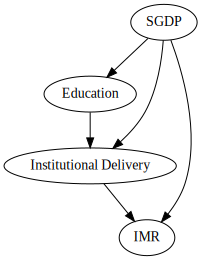

In [ ]:
###### Visualizing causal pathways #######
from graphviz import Digraph

dot = Digraph()

dot.edge("Education", "Institutional Delivery")
dot.edge("Institutional Delivery", "IMR")
dot.edge("SGDP", "Education")
dot.edge("SGDP", "Institutional Delivery")
dot.edge("SGDP", "IMR")

dot


In [ ]:
vars_needed = [
    "Women (age 15-49) who are literate4 (%)",
    "Institutional births (in the 5 years before the survey) (%)",
    "Infant mortality rate (per 1000 live births)",
    "Per Capita GSDP - 2020-2021",
    "Women (age 15-49 years) having a bank or savings account that they themselves use (%)"
]

df_med = state_total[vars_needed].apply(pd.to_numeric, errors="coerce").dropna()


In [ ]:
### Total Effect ###
import statsmodels.api as sm

X = sm.add_constant(df_med[
    ["Women (age 15-49) who are literate4 (%)",
     "Per Capita GSDP - 2020-2021"]
])
Y = df_med["Infant mortality rate (per 1000 live births)"]

model_total = sm.OLS(Y, X).fit()
model_total.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                         OLS Regression Results                                         
========================================================================================================
Dep. Variable:     Infant mortality rate (per 1000 live births)   R-squared:                       0.618
Model:                                                      OLS   Adj. R-squared:                  0.588
Method:                                           Least Squares   F-statistic:                     20.23
Date:                                          Sat, 21 Feb 2026   Prob (F-statistic):           5.95e-06
Time:                                                  03:43:53   Log-Likelihood:                -94.092
No. Observations:                                            28   AIC:                             194.2
Df Residuals:                                                25   BIC:                             198.2
Df Model:                                                     2                                         
Covariance Type:                                      nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      77.2767     11.655      6.630      0.000      53.272     101.281
Women (age 15-49) who are literate4 (%)    -0.4975      0.161     -3.100      0.005      -0.828      -0.167
Per Capita GSDP - 2020-2021             -5.214e-05   1.56e-05     -3.350      0.003   -8.42e-05   -2.01e-05
==============================================================================
Omnibus:                        0.952   Durbin-Watson:                   1.732
Prob(Omnibus):                  0.621   Jarque-Bera (JB):                0.472
Skew:                          -0.318   Prob(JB):                        0.790
Kurtosis:                       3.023   Cond. No.                     1.75e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.75e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
X_m = sm.add_constant(df_med[
    ["Women (age 15-49) who are literate4 (%)",
     "Per Capita GSDP - 2020-2021"]
])
M = df_med["Institutional births (in the 5 years before the survey) (%)"]

model_mediator = sm.OLS(M, X_m).fit()
model_mediator.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                                 OLS Regression Results                                                
=======================================================================================================================
Dep. Variable:     Institutional births (in the 5 years before the survey) (%)   R-squared:                       0.276
Model:                                                                     OLS   Adj. R-squared:                  0.219
Method:                                                          Least Squares   F-statistic:                     4.775
Date:                                                         Sat, 21 Feb 2026   Prob (F-statistic):             0.0175
Time:                                                                 03:43:55   Log-Likelihood:                -105.09
No. Observations:                                                           28   AIC:                             216.2
Df Residuals:                                                               25   BIC:                             220.2
Df Model:                                                                    2                                         
Covariance Type:                                                     nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                     100.3846     17.262      5.815      0.000      64.833     135.936
Women (age 15-49) who are literate4 (%)    -0.3294      0.238     -1.386      0.178      -0.819       0.160
Per Capita GSDP - 2020-2021              7.117e-05   2.31e-05      3.087      0.005    2.37e-05       0.000
==============================================================================
Omnibus:                       19.687   Durbin-Watson:                   2.317
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.270
Skew:                          -1.674   Prob(JB):                     1.97e-06
Kurtosis:                       6.362   Cond. No.                     1.75e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.75e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
X_full = sm.add_constant(df_med[
    ["Women (age 15-49) who are literate4 (%)",
     "Institutional births (in the 5 years before the survey) (%)",
     "Per Capita GSDP - 2020-2021"]
])

model_direct = sm.OLS(Y, X_full).fit()
model_direct.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                         OLS Regression Results                                         
========================================================================================================
Dep. Variable:     Infant mortality rate (per 1000 live births)   R-squared:                       0.619
Model:                                                      OLS   Adj. R-squared:                  0.571
Method:                                           Least Squares   F-statistic:                     13.00
Date:                                          Sat, 21 Feb 2026   Prob (F-statistic):           3.04e-05
Time:                                                  03:43:56   Log-Likelihood:                -94.060
No. Observations:                                            28   AIC:                             196.1
Df Residuals:                                                24   BIC:                             201.4
Df Model:                                                     3                                         
Covariance Type:                                      nonrobust                                         
===============================================================================================================================
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
const                                                          80.5192     18.225      4.418      0.000      42.904     118.134
Women (age 15-49) who are literate4 (%)                        -0.5081      0.170     -2.993      0.006      -0.859      -0.158
Institutional births (in the 5 years before the survey) (%)    -0.0323      0.138     -0.235      0.816      -0.316       0.252
Per Capita GSDP - 2020-2021                                 -4.984e-05   1.86e-05     -2.673      0.013   -8.83e-05   -1.14e-05
==============================================================================
Omnibus:                        1.039   Durbin-Watson:                   1.739
Prob(Omnibus):                  0.595   Jarque-Bera (JB):                0.489
Skew:                          -0.322   Prob(JB):                        0.783
Kurtosis:                       3.070   Cond. No.                     2.69e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.69e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
###### Proportion mediated ######

beta_total = model_total.params[1]
beta_direct = model_direct.params[1]

print("Proportion mediated (in %) = ", (beta_total - beta_direct) / beta_total *100)


Proportion mediated (in %) =  -2.138572804253178


/tmp/ipython-input-963244938.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_total = model_total.params[1]
/tmp/ipython-input-963244938.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_direct = model_direct.params[1]


In [ ]:
######### Correlation-based clustering ##########

# distance_matrix = 1 - pcorr_matrix.abs()

# # Numerical safety
# np.fill_diagonal(distance_matrix.values, 0)

# print(df_clean.shape)
# print(nfhs_data.shape)

# Correlation matrix across indicators
corr_matrix = df_clean.corr(method="pearson", numeric_only=True)
# print(corr_matrix.shape)

# Distance matrix: D = 1 - |correlation|
distance_matrix = 1 - corr_matrix.abs()

# Fill diagonal with 0 explicitly (numerical safety)
np.fill_diagonal(distance_matrix.values, 0)

In [ ]:
from scipy.spatial.distance import squareform

condensed_dist = squareform(distance_matrix.values)

from scipy.cluster.hierarchy import linkage, dendrogram

# Ward is not valid for arbitrary distance matrices
# Use 'average' or 'complete'
Z = linkage(condensed_dist, method="average")


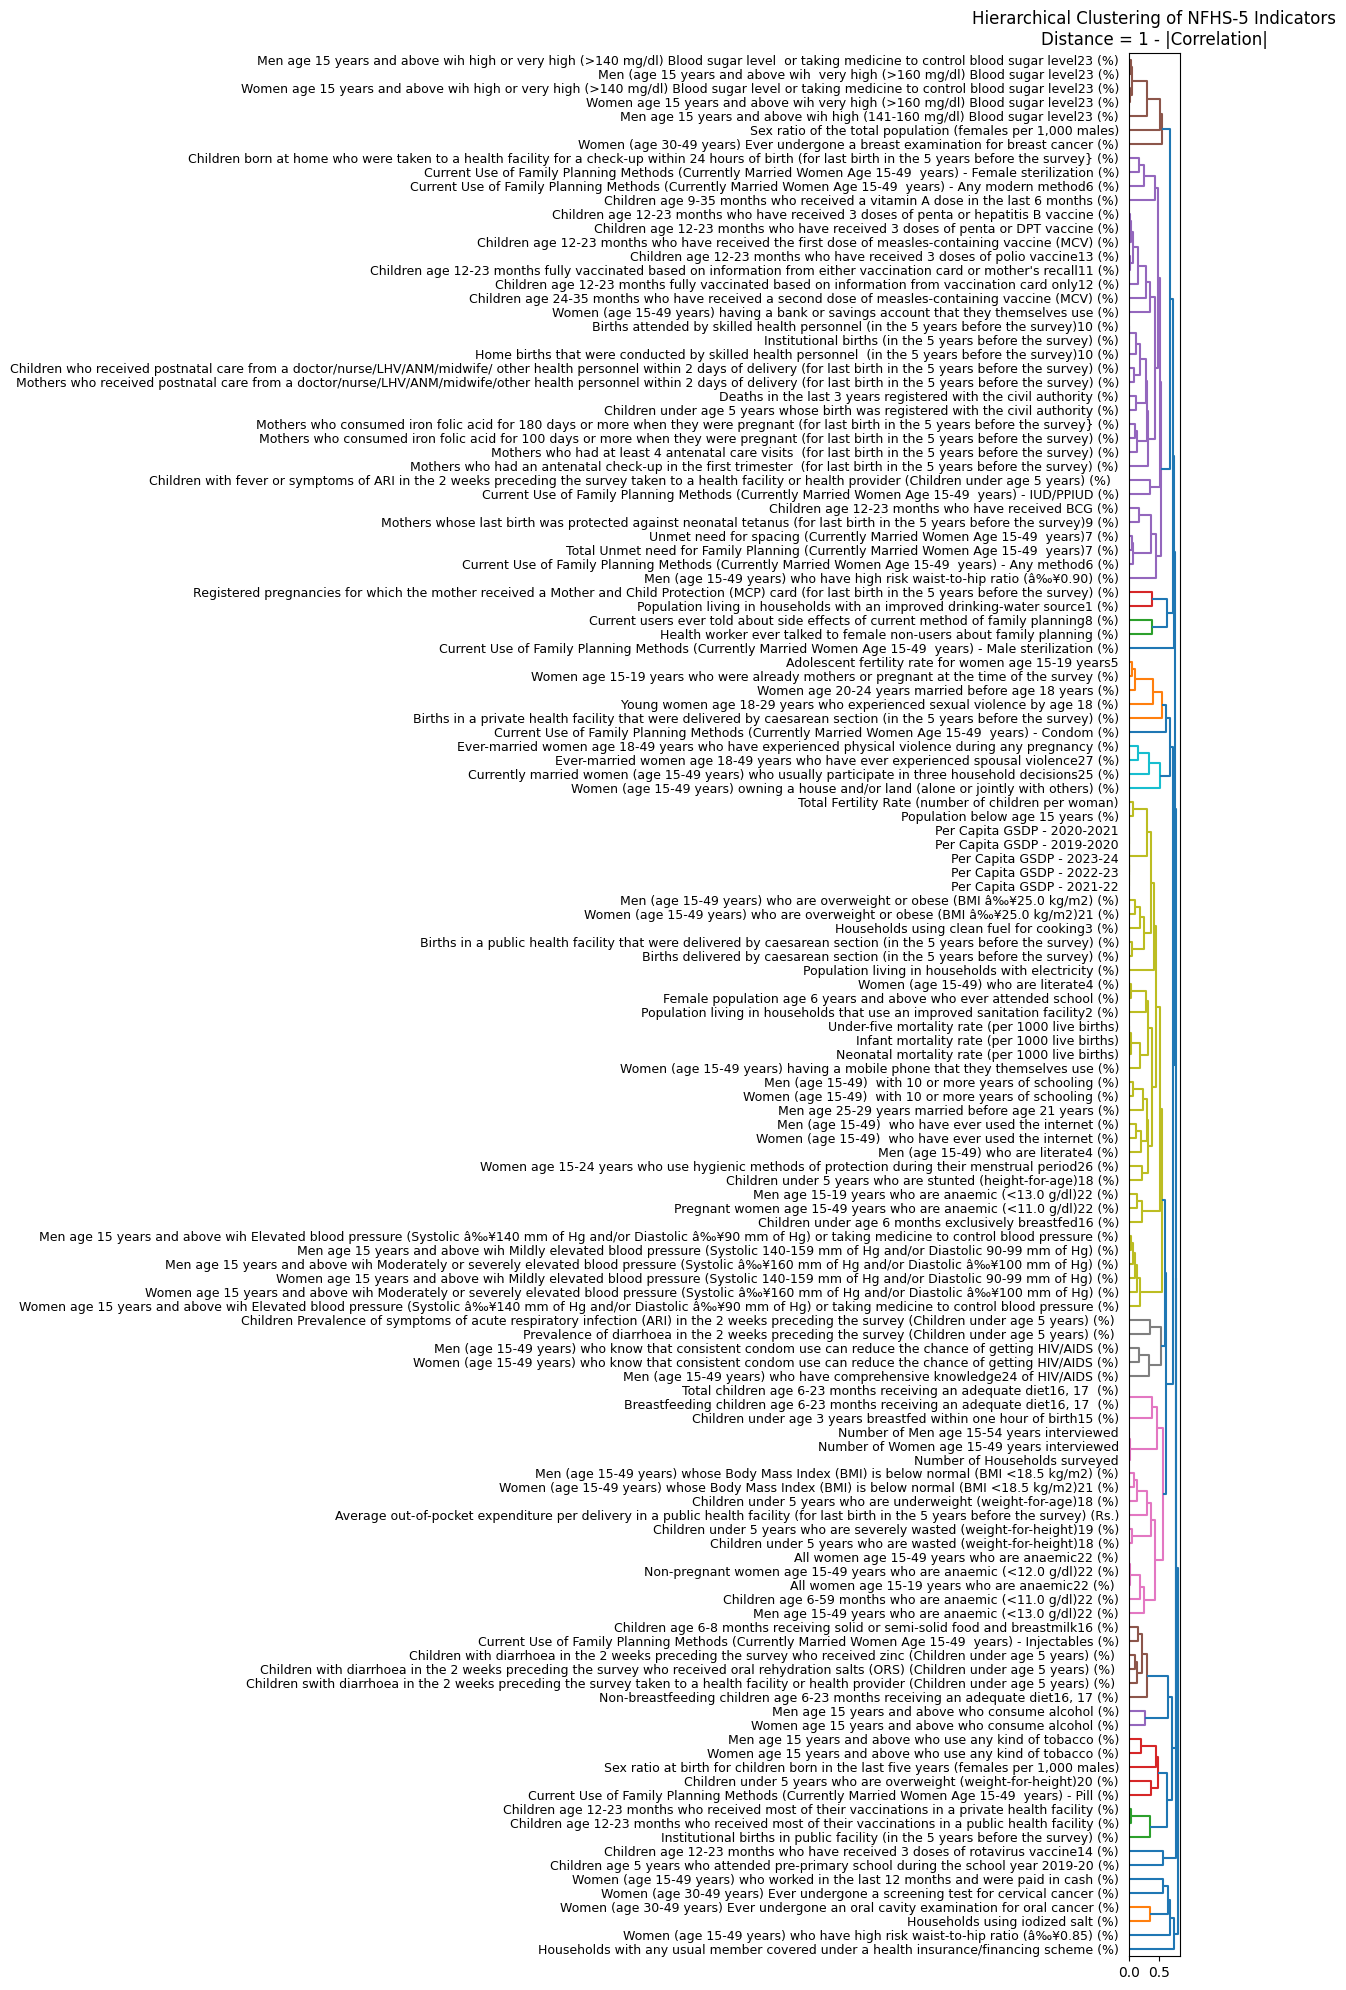

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 20))
dendrogram(
    Z,
    labels=distance_matrix.index,
    orientation="right",
    leaf_font_size=9
)
plt.title("Hierarchical Clustering of NFHS-5 Indicators\nDistance = 1 - |Correlation|")
plt.tight_layout()
plt.show()


In [ ]:
## Extract Clusters ##
from scipy.cluster.hierarchy import fcluster

# Example: cluster indicators with |corr| ≥ 0.7
threshold = 0.5   # because D = 1 - |corr|
clusters = fcluster(Z, t=threshold, criterion="distance")

cluster_df = pd.DataFrame({
    "Indicator": distance_matrix.index,
    "Cluster": clusters
}).sort_values("Cluster")

print(cluster_df)
print(cluster_df.size)


                                             Indicator  Cluster
13                   Households using iodized salt (%)        1
114  Women (age 30-49 years) Ever undergone an oral...        1
112  Women (age 30-49 years) Ever undergone a scree...        2
119  Women (age 15-49 years) who worked in the last...        3
92   Women (age 15-49 years) who have high risk wai...        4
..                                                 ...      ...
102  Women age 15 years and above wih high or very ...       29
101  Women age 15 years and above wih very high (>1...       29
5     Sex ratio of the total population (females pe...       30
113  Women (age 30-49 years) Ever undergone a breas...       31
33   Current Use of Family Planning Methods (Curren...       32

[136 rows x 2 columns]
272


In [ ]:
for c in sorted(cluster_df["Cluster"].unique()):
    print(f"\nCluster {c}:")
    print(cluster_df[cluster_df["Cluster"] == c]["Indicator"].tolist())



Cluster 1:
['Households using iodized salt (%)', 'Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%)']

Cluster 2:
['Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%)']

Cluster 3:
['Women (age 15-49 years) who worked in the last 12 months and were paid in cash (%)']

Cluster 4:
['Women (age 15-49 years) who have high risk waist-to-hip ratio (â‰¥0.85) (%)']

Cluster 5:
['Households with any usual member covered under a health insurance/financing scheme (%)']

Cluster 6:
['Children age 5 years who attended pre-primary school during the school year 2019-20 (%)']

Cluster 7:
['Children age 12-23 months who have received 3 doses of rotavirus vaccine14 (%)']

Cluster 8:
['Children age 12-23 months who received most of their vaccinations in a private health facility (%)', 'Children age 12-23 months who received most of their vaccinations in a public health facility (%)', 'Institutional births in public facility (in the 5 years

In [ ]:
########### GRAPH BASED CLUSTERING ############
import networkx as nx
import numpy as np

# Threshold for edge creation
CORR_THRESHOLD = 0.6

G = nx.Graph()

# Add nodes
for indicator in corr_matrix.columns:
    G.add_node(indicator)

# Add edges for strong correlations
for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i >= j:
            continue
        corr_val = corr_matrix.loc[i, j]
        if pd.notna(corr_val) and abs(corr_val) >= CORR_THRESHOLD:
            G.add_edge(
                i,
                j,
                weight=abs(corr_val),
                sign="positive" if corr_val > 0 else "negative"
            )

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")


Graph has 136 nodes and 785 edges


In [ ]:
!pip install python-louvain


In [ ]:
from community.community_louvain import best_partition

# Louvain partition
louvain_partition = best_partition(
    G,
    weight="weight",
    resolution=4.0
)

# Convert to DataFrame
louvain_df = pd.DataFrame({
    "Indicator": louvain_partition.keys(),
    "Louvain_Community": louvain_partition.values()
}).sort_values("Louvain_Community")

louvain_df.head()

,Indicator,Louvain_Community
18,Women (age 15-49) with 10 or more years of sc...,0
53,Institutional births in public facility (in th...,0
69,Children age 12-23 months who received most of...,0
70,Children age 12-23 months who received most of...,0
11,Population living in households that use an im...,1


In [ ]:
for c in sorted(louvain_df["Louvain_Community"].unique()):
    print(f"\n🟦 Louvain Module {c}")
    indicators = louvain_df[louvain_df["Louvain_Community"] == c]["Indicator"]
    for ind in indicators:
        print("  -", ind)



🟦 Louvain Module 0
  - Women (age 15-49)  with 10 or more years of schooling (%)
  - Institutional births in public facility (in the 5 years before the survey) (%)
  - Children age 12-23 months who received most of their vaccinations in a public health facility (%)
  - Children age 12-23 months who received most of their vaccinations in a private health facility (%)

🟦 Louvain Module 1
  - Population living in households that use an improved sanitation facility2 (%)
  - Children under age 3 years breastfed within one hour of birth15 (%)
  - Women (age 15-49) who are literate4 (%)
  - Female population age 6 years and above who ever attended school (%)
  - Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%)
  - Ever-married women age 18-49 years who have ever experienced spousal violence27 (%)
  - Currently married women (age 15-49 years) who usually participate in three household decisions25 (%)

🟦 Louvain Module 2
  - Children Prevalence

In [ ]:
!pip install igraph leidenalg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 20.9 MB/s eta 0:00:00


In [ ]:
import igraph as ig
import leidenalg

# Map node names to indices
nodes = list(G.nodes())
node_index = {node: i for i, node in enumerate(nodes)}

edges = []
weights = []

for u, v, data in G.edges(data=True):
    edges.append((node_index[u], node_index[v]))
    weights.append(data["weight"])

ig_graph = ig.Graph(
    n=len(nodes),
    edges=edges,
    edge_attrs={"weight": weights}
)


In [ ]:
leiden_partition = leidenalg.find_partition(
    ig_graph,
    leidenalg.RBConfigurationVertexPartition,
    weights=ig_graph.es["weight"],
    resolution_parameter=4.0
)

leiden_df = pd.DataFrame({
    "Indicator": nodes,
    "Leiden_Community": leiden_partition.membership
}).sort_values("Leiden_Community")

leiden_df.head()


,Indicator,Leiden_Community
7,Children under age 5 years whose birth was reg...,0
8,Deaths in the last 3 years registered with the...,0
54,Home births that were conducted by skilled hea...,0
52,Institutional births (in the 5 years before th...,0
48,Mothers who received postnatal care from a doc...,0


In [ ]:
for c in sorted(leiden_df["Leiden_Community"].unique()):
    print(f"\n🟩 Leiden Module {c}")
    inds = leiden_df[leiden_df["Leiden_Community"] == c]["Indicator"]
    for ind in inds:
        print("  -", ind)



🟩 Leiden Module 0
  - Children under age 5 years whose birth was registered with the civil authority (%)
  - Deaths in the last 3 years registered with the civil authority (%)
  - Home births that were conducted by skilled health personnel  (in the 5 years before the survey)10 (%)
  - Institutional births (in the 5 years before the survey) (%)
  - Mothers who received postnatal care from a doctor/nurse/LHV/ANM/midwife/other health personnel within 2 days of delivery (for last birth in the 5 years before the survey) (%)
  - Births attended by skilled health personnel (in the 5 years before the survey)10 (%)
  - Mothers who had an antenatal check-up in the first trimester  (for last birth in the 5 years before the survey) (%)
  - Current Use of Family Planning Methods (Currently Married Women Age 15-49  years) - IUD/PPIUD (%)
  - Children with fever or symptoms of ARI in the 2 weeks preceding the survey taken to a health facility or health provider (Children under age 5 years) (%)  
  -

In [ ]:
from sklearn.cluster import SpectralClustering

# Similarity = |correlation|
similarity_matrix = corr_matrix.abs().fillna(0)

k = 25

spectral = SpectralClustering(
    n_clusters=k,
    affinity="precomputed",
    random_state=42
)

labels = spectral.fit_predict(similarity_matrix)

spectral_df = pd.DataFrame({
    "Indicator": similarity_matrix.index,
    "Spectral_Cluster": labels
}).sort_values("Spectral_Cluster")

spectral_df.head()


,Indicator,Spectral_Cluster
40,Health worker ever talked to female non-users ...,0
41,Current users ever told about side effects of ...,0
12,Households using clean fuel for cooking3 (%),1
10,Population living in households with an improv...,1
21,Men (age 15-49) who have ever used the intern...,1


In [ ]:
for c in sorted(spectral_df["Spectral_Cluster"].unique()):
    print(f"\n🟨 Spectral Cluster {c}")
    inds = spectral_df[spectral_df["Spectral_Cluster"] == c]["Indicator"]
    for ind in inds:
        print("  -", ind)



🟨 Spectral Cluster 0
  - Health worker ever talked to female non-users about family planning (%)
  - Current users ever told about side effects of current method of family planning8 (%)

🟨 Spectral Cluster 1
  - Households using clean fuel for cooking3 (%)
  - Population living in households with an improved drinking-water source1 (%)
  - Men (age 15-49)  who have ever used the internet (%)
  - Children under 5 years who are stunted (height-for-age)18 (%)
  - Women (age 15-49 years) who are overweight or obese (BMI â‰¥25.0 kg/m2)21 (%)
  - Men (age 15-49 years) who are overweight or obese (BMI â‰¥25.0 kg/m2) (%)
  - Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%)
  - Men (age 15-49 years) who know that consistent condom use can reduce the chance of getting HIV/AIDS (%)
  - Women (age 15-49 years) who know that consistent condom use can reduce the chance of getting HIV/AIDS (%)
  - Women (age 30-49 years) Ever undergone a screening test 

In [ ]:
cluster_compare = (
    louvain_df
    .merge(leiden_df, on="Indicator")
    .merge(spectral_df, on="Indicator")
)

cluster_compare.head()


,Indicator,Louvain_Community,Leiden_Community,Spectral_Cluster
0,Women (age 15-49) with 10 or more years of sc...,0,16,3
1,Institutional births in public facility (in th...,0,16,13
2,Children age 12-23 months who received most of...,0,16,13
3,Children age 12-23 months who received most of...,0,16,13
4,Population living in households that use an im...,1,7,2


In [ ]:
############ Propensity Score Matching ###############
treatment_col = "Women (age 15-49) who are literate4 (%)"
outcome_col = "Infant mortality rate (per 1000 live births)"

confounders = [
    "Per Capita GSDP - 2020-2021",
    "Population living in households with electricity (%)"
    # "Population living in households with an improved sanitation facility2 (%)",
    # "Women (age 15-49) having a bank or savings account that they themselves use (%)"
]

# print(df_clean.head(5))
# Clean data
cols_needed = [treatment_col, outcome_col] + confounders

# pd.to_numeric(df_clean.replace("*", np.nan))
df_psm = df_clean[cols_needed]

for c in cols_needed:
    df_psm[c] = pd.to_numeric(df_psm[c], errors="coerce")

df_psm = df_psm.dropna()

# Create treatment indicator
threshold = df_psm[treatment_col].median()

df_psm["treated"] = (
    df_psm[treatment_col] >= threshold
).astype(int)



/tmp/ipython-input-2758523618.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_psm[c] = pd.to_numeric(df_psm[c], errors="coerce")


In [ ]:
# Estimate prop score
from sklearn.linear_model import LogisticRegression

X = df_psm[confounders]
y = df_psm["treated"]

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, y)

df_psm["propensity_score"] = ps_model.predict_proba(X)[:, 1]


In [ ]:
# Nearest neighbour matching
from sklearn.neighbors import NearestNeighbors

treated = df_psm[df_psm["treated"] == 1]
control = df_psm[df_psm["treated"] == 0]

nn = NearestNeighbors(n_neighbors=1)

nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(
    treated[["propensity_score"]]
)

matched_control = control.iloc[indices.flatten()].reset_index(drop=True)
matched_treated = treated.reset_index(drop=True)


In [ ]:
effect = (
    matched_treated[outcome_col] -
    matched_control[outcome_col]
).mean()

print("Estimated causal effect:", effect)


Estimated causal effect: -8.014285714285714


In [ ]:
print("Before matching:")
print(df_psm.groupby("treated")[confounders].mean())

print("\nAfter matching:")
print(pd.concat([
    matched_treated.assign(group="treated"),
    matched_control.assign(group="control")
]).groupby("group")[confounders].mean())


Before matching:
         Per Capita GSDP - 2020-2021  \
treated                                
0                      143452.571429   
1                      222408.142857   

         Population living in households with electricity (%)  
treated                                                        
0                                                96.757143     
1                                                98.528571     

After matching:
         Per Capita GSDP - 2020-2021  \
group                                  
control                198341.000000   
treated                222408.142857   

         Population living in households with electricity (%)  
group                                                          
control                                          98.285714     
treated                                          98.528571     


In [ ]:
!pip install causal-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
############# Causal Discovery ###############
from sklearn.cluster import AgglomerativeClustering

# distance_matrix already computed earlier
clustering = AgglomerativeClustering(
    n_clusters=32,
    metric="precomputed",
    linkage="average"
)

cluster_labels = clustering.fit_predict(distance_matrix)

# Use the index of the distance_matrix as the indicators for the cluster_df
# because cluster_labels are generated based on these indicators.
cluster_map = dict(zip(distance_matrix.index, cluster_labels))

cluster_df = pd.DataFrame({
    "Indicator": distance_matrix.index, # Changed from indicator_cols
    "Cluster": cluster_labels
})

cluster_df.sort_values("Cluster")

,Indicator,Cluster
6,Sex ratio at birth for children born in the la...,0
35,Current Use of Family Planning Methods (Curren...,0
127,Women age 15 years and above who use any kind ...,0
87,Children under 5 years who are overweight (wei...,0
128,Men age 15 years and above who use any kind of...,0
...,...,...
96,Pregnant women age 15-49 years who are anaemic...,28
120,Women (age 15-49 years) owning a house and/or ...,29
5,Sex ratio of the total population (females pe...,30
76,Children with fever or symptoms of ARI in the ...,31


In [ ]:
cluster_data = pd.DataFrame()

for c in set(cluster_labels):
    cols = cluster_df[cluster_df.Cluster == c]["Indicator"]
    cluster_data[f"cluster_{c}"] = df_clean[cols].mean(axis=1)


In [ ]:
from causallearn.search.ConstraintBased.PC import pc

data = cluster_data.dropna().values

cg = pc(data)

print(cg.G)


/usr/local/lib/python3.12/dist-packages/causallearn/search/ConstraintBased/PC.py:36: UserWarning: The number of features is much larger than the sample size!
  warnings.warn("The number of features is much larger than the sample size!")


  0%|          | 0/32 [00:00<?, ?it/s]

Graph Nodes:
X1;X2;X3;X4;X5;X6;X7;X8;X9;X10;X11;X12;X13;X14;X15;X16;X17;X18;X19;X20;X21;X22;X23;X24;X25;X26;X27;X28;X29;X30;X31;X32

Graph Edges:
1. X3 --> X2
2. X6 --> X2
3. X9 --> X2
4. X3 --- X12
5. X3 --- X20
6. X4 --> X11
7. X7 --> X11
8. X9 --- X31
9. X10 --- X13
10. X10 --- X14
11. X23 --- X30



In [ ]:
cluster_id = 4

cols = cluster_df[
    cluster_df.Cluster == cluster_id
]["Indicator"].tolist()

subdata = df_clean[cols].dropna()

cg_local = pc(subdata.values)

print(cg_local.G)


  0%|          | 0/6 [00:00<?, ?it/s]

Graph Nodes:
X1;X2;X3;X4;X5;X6

Graph Edges:
1. X1 --- X2
2. X2 --- X3
3. X5 --- X6



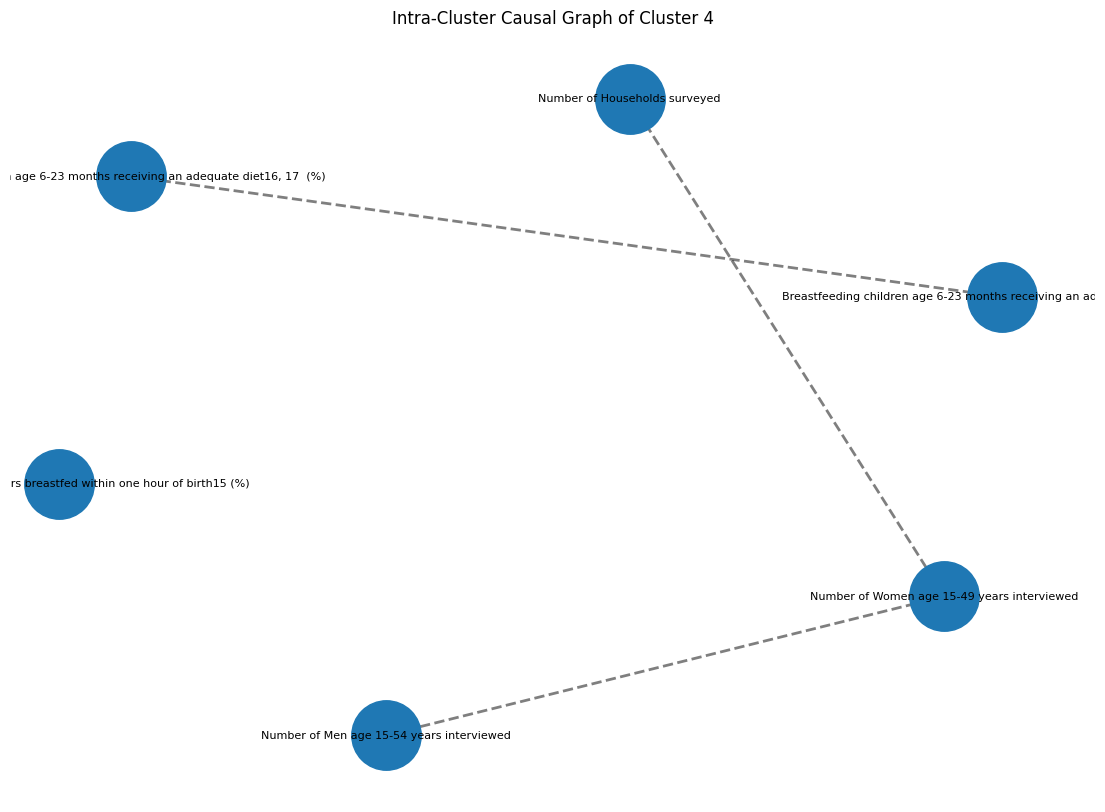

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G_dir = nx.DiGraph()
G_undir = nx.Graph()

adj = cg_local.G.graph

# Add nodes
for name in cols:
    G_dir.add_node(name)
    G_undir.add_node(name)

# Decode PC edges
for i in range(adj.shape[0]):
    for j in range(i+1, adj.shape[1]):

        # Directed edge
        if adj[i,j] == 1 and adj[j,i] == -1:
            G_dir.add_edge(cols[i], cols[j])

        elif adj[j,i] == 1 and adj[i,j] == -1:
            G_dir.add_edge(cols[j], cols[i])

        # Undirected edge
        elif adj[i,j] == -1 and adj[j,i] == -1:
            G_undir.add_edge(cols[i], cols[j])

### Plot DAG ###
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G_dir, seed=42)

# Draw undirected edges first
nx.draw_networkx_edges(
    G_undir,
    pos,
    style="dashed",
    width=2, alpha = 0.5
)

# Draw directed edges
nx.draw_networkx_edges(
    G_dir,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=25,
    width=2,
    edge_color='black',
    alpha=0.8,
    # For offset of arrowheads
    min_source_margin=15,
    min_target_margin=25
)

# Draw nodes + labels
nx.draw_networkx_nodes(G_dir, pos, node_size=2500)
nx.draw_networkx_labels(G_dir, pos, font_size=8)

plt.title(f"Intra-Cluster Causal Graph of Cluster {cluster_id}")
plt.axis("off")
plt.show()


In [ ]:
# Labelling Clusters
# Keyword → theme dictionary
theme_keywords = {
    "Education": ["literate", "school", "education"],
    "Health": ["blood", "cancer", "health", "mortality", "death", "pregnancy", "vaccine", "vaccination", "bmi", "breastfed"],
    "Infrastructure": ["electricity", "sanitation", "water", "housing", "fuel", "spacing"],
    "Economy": ["bank", "employment", "income"],
    "Nutrition": ["stunting", "wasting", "nutrition", "anaemic", "bmi", "breastfed"],
    "Socioeconomic": ["sex ratio", "internet", "fertility", "family planning", "HIV", "tobacco", "alcohol"],
    "Women empowerment": ["pregnancy", "bank", "menstrual", "postnatal", "antenatal", "cervical", "breast", "married women", "paid in cash", "phone", "violence" ],
    "Others": [ "number of", "population"]
}

cluster_labels_map = {}

for cluster_id in cluster_df["Cluster"].unique():

    indicators = cluster_df[
        cluster_df["Cluster"] == cluster_id
    ]["Indicator"].str.lower()

    scores = {theme: 0 for theme in theme_keywords}

    for ind in indicators:
        for theme, keywords in theme_keywords.items():
            if any(k in ind for k in keywords):
                scores[theme] += 1

    best_theme = max(scores, key=scores.get)

    # fallback label
    if scores[best_theme] == 0:
        best_theme = f"Cluster_{cluster_id}"

    cluster_labels_map[cluster_id] = best_theme

cluster_labels_map




{np.int64(4): 'Others',
 np.int64(2): 'Health',
 np.int64(30): 'Socioeconomic',
 np.int64(0): 'Socioeconomic',
 np.int64(1): 'Health',
 np.int64(3): 'Infrastructure',
 np.int64(6): 'Health',
 np.int64(23): 'Health',
 np.int64(20): 'Education',
 np.int64(12): 'Socioeconomic',
 np.int64(5): 'Women empowerment',
 np.int64(27): 'Socioeconomic',
 np.int64(31): 'Health',
 np.int64(18): 'Socioeconomic',
 np.int64(19): 'Women empowerment',
 np.int64(7): 'Socioeconomic',
 np.int64(10): 'Nutrition',
 np.int64(15): 'Health',
 np.int64(24): 'Health',
 np.int64(17): 'Health',
 np.int64(9): 'Cluster_9',
 np.int64(28): 'Nutrition',
 np.int64(25): 'Cluster_25',
 np.int64(8): 'Health',
 np.int64(11): 'Health',
 np.int64(21): 'Health',
 np.int64(26): 'Health',
 np.int64(13): 'Cluster_13',
 np.int64(22): 'Women empowerment',
 np.int64(16): 'Women empowerment',
 np.int64(29): 'Cluster_29',
 np.int64(14): 'Socioeconomic'}

In [ ]:
cluster_df["Theme"] = cluster_df["Cluster"].map(cluster_labels_map)

cluster_df.sort_values("Cluster")

,Indicator,Cluster,Theme
6,Sex ratio at birth for children born in the la...,0,Socioeconomic
35,Current Use of Family Planning Methods (Curren...,0,Socioeconomic
127,Women age 15 years and above who use any kind ...,0,Socioeconomic
87,Children under 5 years who are overweight (wei...,0,Socioeconomic
128,Men age 15 years and above who use any kind of...,0,Socioeconomic
...,...,...,...
96,Pregnant women age 15-49 years who are anaemic...,28,Nutrition
120,Women (age 15-49 years) owning a house and/or ...,29,Cluster_29
5,Sex ratio of the total population (females pe...,30,Socioeconomic
76,Children with fever or symptoms of ARI in the ...,31,Health


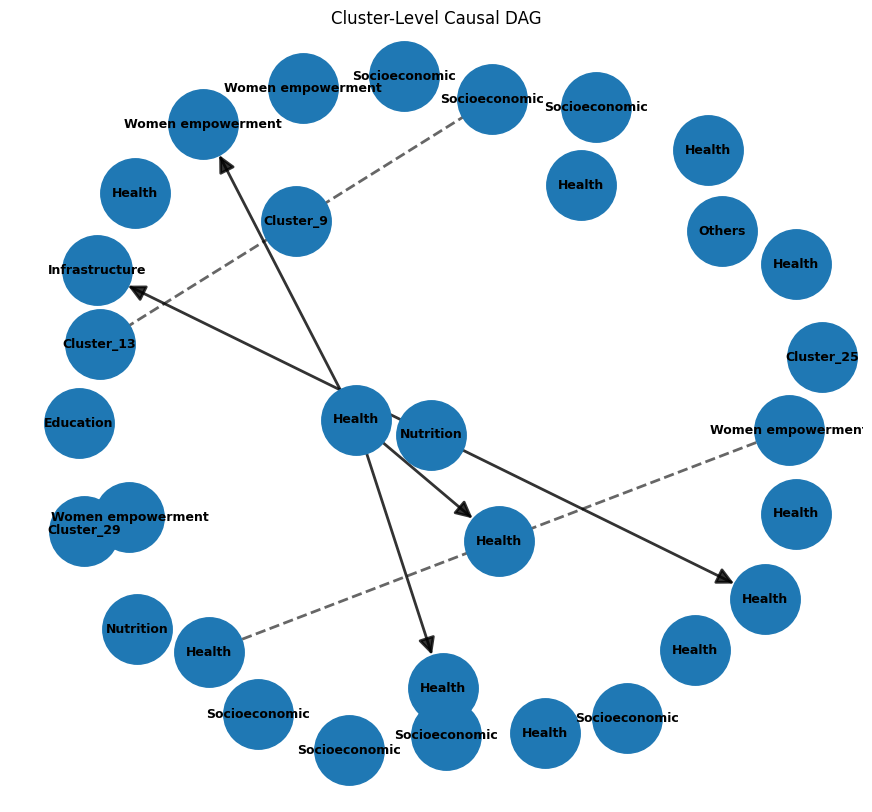

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

adj = cg.G.graph
n = adj.shape[0]

# Create graphs
G_dir = nx.DiGraph()
G_undir = nx.Graph()

# Add nodes (ensure index alignment)
for i in range(n):
    label = cluster_labels_map.get(i, f"C{i}")
    G_dir.add_node(i, label=label)
    G_undir.add_node(i, label=label)

# Decode adjacency matrix
for i in range(n):
    for j in range(i + 1, n):

        if adj[i, j] == 1 and adj[j, i] == -1:
            G_dir.add_edge(i, j)

        elif adj[j, i] == 1 and adj[i, j] == -1:
            G_dir.add_edge(j, i)

        elif adj[i, j] == -1 and adj[j, i] == -1:
            G_undir.add_edge(i, j)

# Combined graph for layout
G_layout = nx.DiGraph()
G_layout.add_nodes_from(G_dir.nodes(data=True))
G_layout.add_edges_from(G_dir.edges())
G_layout.add_edges_from(G_undir.edges())

pos = nx.spring_layout(G_layout, seed=42)

labels = nx.get_node_attributes(G_layout, "label")

plt.figure(figsize=(11, 10))

# Undirected edges
nx.draw_networkx_edges(
    G_undir,
    pos,
    style="dashed",
    width=2,
    alpha = 0.6
)

# Directed edges
nx.draw_networkx_edges(
    G_dir,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=25,
    width=2,
    edge_color='black',
    alpha=0.8,
    # For offset of arrowheads
    min_source_margin=15,
    min_target_margin=25
)
# nx.draw_networkx_edges(
#     G_dir,
#     pos,
#     arrows=True,
#     arrowstyle="->",
#     width=2
# )

# Nodes
nx.draw_networkx_nodes(
    G_layout,
    pos,
    node_size=2500
)

nx.draw_networkx_labels(
    G_layout,
    pos,
    labels,
    font_size=9,
    font_weight="bold"
)

plt.title("Cluster-Level Causal DAG")
plt.axis("off")
plt.show()
# print("Directed edges:", G_dir.edges())
# print("Undirected edges:", G_undir.edges())



# import networkx as nx
# import matplotlib.pyplot as plt

# # adj is the adjacency matrix from the PC algorithm, representing causal relationships between clusters
# adj = cg.G.graph # cg.G.graph has integer indices 0 to k-1 for clusters

# # Create directed and undirected graphs specifically for the causal relationships between clusters
# G_cluster_causal_dir = nx.DiGraph()
# G_cluster_causal_undir = nx.Graph()

# # Add nodes to the cluster-level graphs. The nodes are the cluster IDs (integers).
# # We also add their themes as node attributes for later use in plotting.
# for cluster_id in cluster_labels_map.keys(): # Keys are cluster IDs (integers)
#     theme = cluster_labels_map[cluster_id]
#     G_cluster_causal_dir.add_node(cluster_id, label=theme)
#     G_cluster_causal_undir.add_node(cluster_id, label=theme)

# # Decode PC edges and add them to the cluster-level graphs
# for i in range(adj.shape[0]):
#     for j in range(adj.shape[1]):
#         if i == j: continue # Skip self-loops

#         # Directed edge: adj[i,j] = 1 and adj[j,i] = -1 means i -> j
#         if adj[i, j] == 1 and adj[j, i] == -1:
#             G_cluster_causal_dir.add_edge(i, j)
#         # Directed edge: adj[j,i] = 1 and adj[i,j] = -1 means j -> i
#         elif adj[j, i] == 1 and adj[i, j] == -1:
#             G_cluster_causal_dir.add_edge(j, i)
#         # Undirected edge: adj[i,j] == -1 and adj[j,i] == -1 means i --- j
#         elif adj[i, j] == -1 and adj[j, i] == -1:
#             G_cluster_causal_undir.add_edge(i, j)

# # The global 'G' from k9rBZQfIouYw (indicator-level graph) is no longer being modified here.
# # The 'cols' variable is not needed for cluster-level plotting.

In [ ]:
import networkx as nx

def pc_to_networkx(adj, node_names):

    G = nx.DiGraph()

    for i, name in enumerate(node_names):
        G.add_node(name)

    k = adj.shape[0]

    for i in range(k):
        for j in range(i+1, k):

            if adj[i,j] == 1 and adj[j,i] == -1:
                G.add_edge(node_names[i], node_names[j])

            elif adj[j,i] == 1 and adj[i,j] == -1:
                G.add_edge(node_names[j], node_names[i])

            elif adj[i,j] == -1 and adj[j,i] == -1:
                G.add_edge(node_names[i], node_names[j])
                G.add_edge(node_names[j], node_names[i])

    return G


In [ ]:
## Extracting only the health and women_empowerment theme causal pathways ##

def assign_theme(indicator, theme_keywords):
    name = indicator.lower()

    for theme, keywords in theme_keywords.items():
        for word in keywords:
            if word.lower() in name:
                return theme

    return "Others"

allowed_themes = {"Health", "Women empowerment"}

all_cluster_paths = {}

for cluster_id in sorted(set(cluster_labels)):

    print("\n============================")
    print("Cluster:", cluster_id)
    print("============================")

    cols = cluster_df[
        cluster_df.Cluster == cluster_id
    ]["Indicator"].tolist()

    if len(cols) < 2:
        print("Too small — skipping")
        continue

    subdata = df_clean[cols].dropna()

    if subdata.shape[0] < 5:
        print("Insufficient samples — skipping")
        continue

    try:

        cg_local = pc(subdata.values)

        adj = cg_local.G.graph

        G_cluster = pc_to_networkx(adj, cols)

    except Exception as e:
        print("PC failed:", e)
        continue

    # --------------------------------
    # Theme tagging
    # --------------------------------

    node_theme = {
        n: assign_theme(n, theme_keywords)
        for n in G_cluster.nodes()
    }

    valid_nodes = [
        n for n in G_cluster.nodes()
        if node_theme[n] in allowed_themes
    ]

    G_filtered = G_cluster.subgraph(valid_nodes).copy()

    # --------------------------------
    # Extract causal paths
    # --------------------------------

    paths = []

    for s in G_filtered.nodes():
        for t in G_filtered.nodes():

            if s == t:
                continue

            try:
                for p in nx.all_simple_paths(G_filtered, s, t):
                    paths.append(p)

            except nx.NetworkXNoPath:
                pass

    all_cluster_paths[cluster_id] = paths

    # --------------------------------
    # Print results
    # --------------------------------

    if paths:

        print("\nHealth ↔ Women empowerment paths:\n")

        for p in paths:
            themed = [(n, node_theme[n]) for n in p]
            print(themed)

    else:
        print("No valid theme paths found")

# node_theme = {}

# for node in cg_local.nodes():   # your intra-cluster graph
#     node_theme[node] = assign_theme(node, theme_keywords)

# for n, t in node_theme.items():
#     print(n, "→", t)

# allowed_themes = {"Health", "Women empowerment"}

# valid_nodes = [
#     n for n in cg_local.nodes()
#     if node_theme[n] in allowed_themes
# ]

# G_filtered = cg_local.subgraph(valid_nodes).copy()

# ## Extract causal paths

# import networkx as nx

# paths = []

# for source in G_filtered.nodes():
#     for target in G_filtered.nodes():

#         if source == target:
#             continue

#         try:
#             for p in nx.all_simple_paths(G_filtered, source, target):
#                 paths.append(p)

#         except nx.NetworkXNoPath:
#             pass
# print("\n=== Health ↔ Women Empowerment causal paths ===\n")

# for p in paths:
#     themed = [(node, node_theme[node]) for node in p]
#     print(themed)



Cluster: 0


  0%|          | 0/5 [00:00<?, ?it/s]

No valid theme paths found

Cluster: 1


  0%|          | 0/23 [00:00<?, ?it/s]


Health ↔ Women empowerment paths:

[('Mothers who had an antenatal check-up in the first trimester  (for last birth in the 5 years before the survey) (%)', 'Women empowerment'), ('Mothers who had at least 4 antenatal care visits  (for last birth in the 5 years before the survey) (%)', 'Women empowerment')]
[('Mothers who had an antenatal check-up in the first trimester  (for last birth in the 5 years before the survey) (%)', 'Women empowerment'), ('Mothers who received postnatal care from a doctor/nurse/LHV/ANM/midwife/other health personnel within 2 days of delivery (for last birth in the 5 years before the survey) (%)', 'Health')]
[('Mothers who had an antenatal check-up in the first trimester  (for last birth in the 5 years before the survey) (%)', 'Women empowerment'), ('Mothers who received postnatal care from a doctor/nurse/LHV/ANM/midwife/other health personnel within 2 days of delivery (for last birth in the 5 years before the survey) (%)', 'Health'), ('Children who received p

...


Health ↔ Women empowerment paths:

[('Currently married women (age 15-49 years) who usually participate in three household decisions25 (%)', 'Women empowerment'), ('Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%)', 'Health'), ('Ever-married women age 18-49 years who have ever experienced spousal violence27 (%)', 'Women empowerment')]
[('Currently married women (age 15-49 years) who usually participate in three household decisions25 (%)', 'Women empowerment'), ('Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%)', 'Health')]
[('Ever-married women age 18-49 years who have ever experienced spousal violence27 (%)', 'Women empowerment'), ('Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%)', 'Health'), ('Currently married women (age 15-49 years) who usually participate in three household decisions25 (%)', 'Women empowerment')]
[('Ever-married wo

  0%|          | 0/3 [00:00<?, ?it/s]

No valid theme paths found

Cluster: 29
Too small — skipping

Cluster: 30
Too small — skipping

Cluster: 31


  0%|          | 0/2 [00:00<?, ?it/s]

No valid theme paths found


/usr/local/lib/python3.12/dist-packages/causallearn/search/ConstraintBased/PC.py:36: UserWarning: The number of features is much larger than the sample size!
  warnings.warn("The number of features is much larger than the sample size!")


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

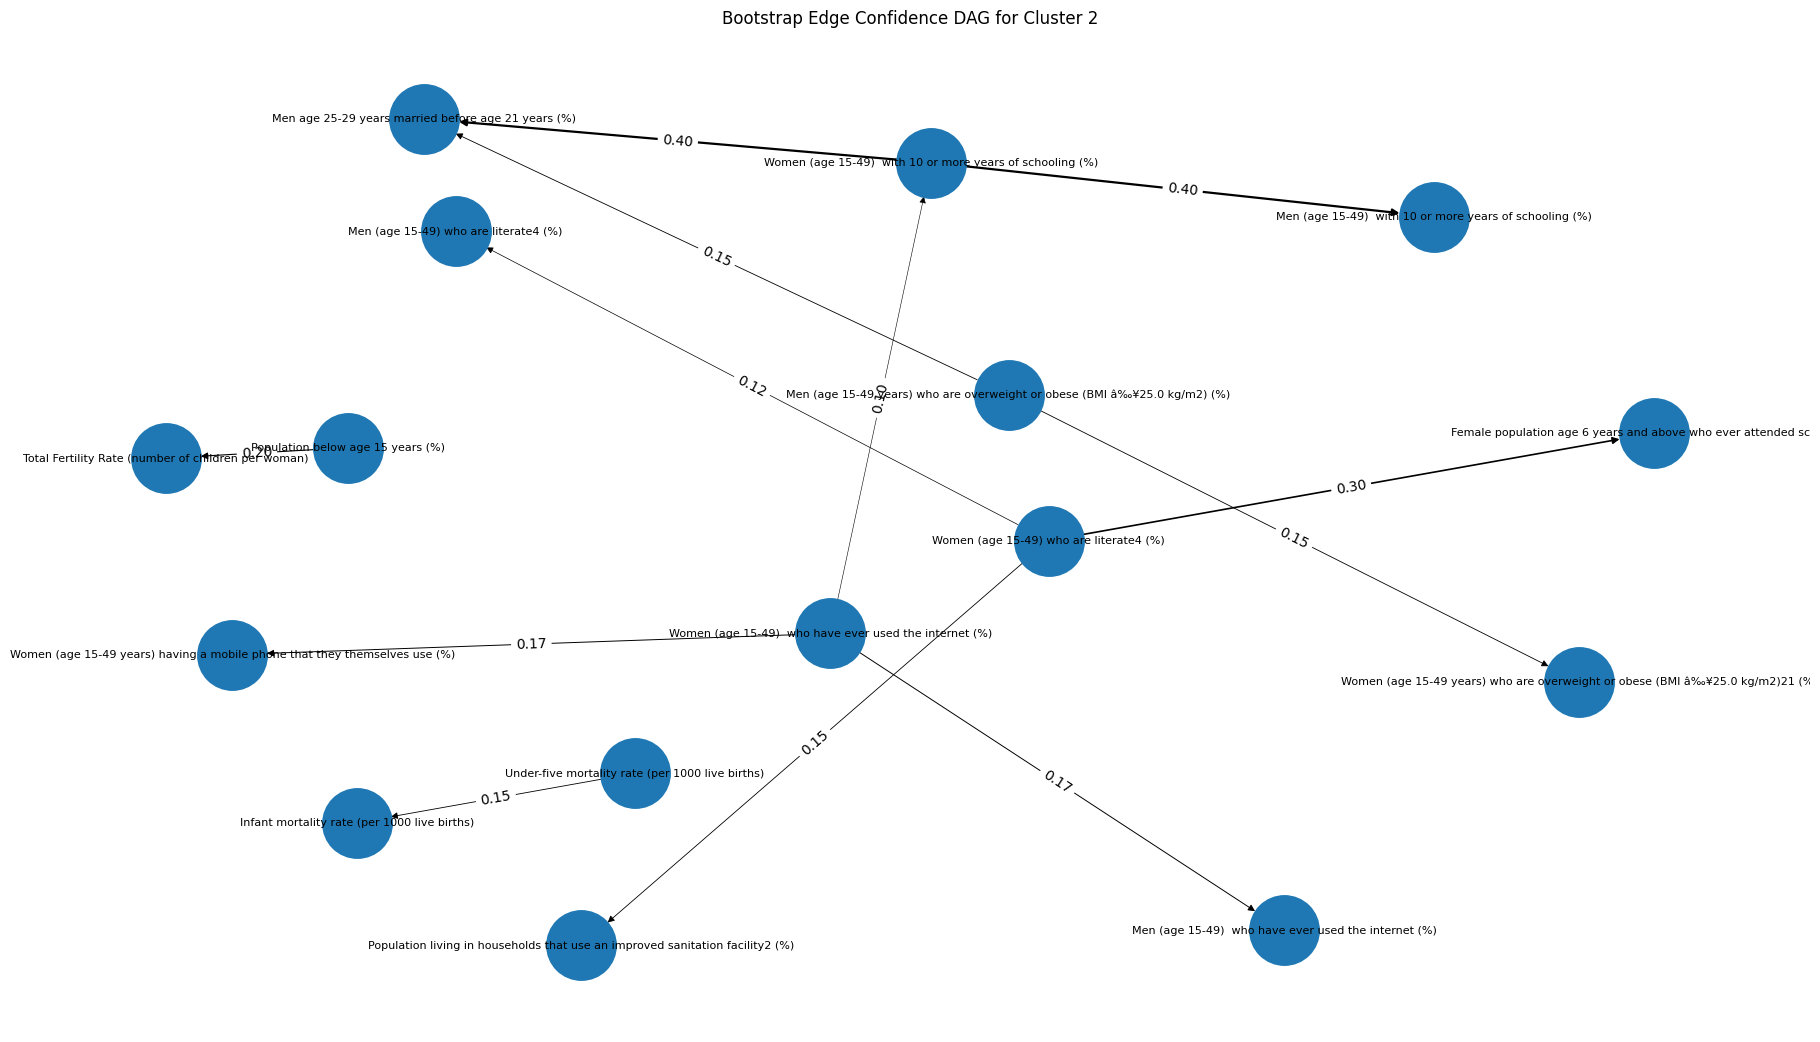

In [ ]:
 ### Edge Confidence via Bootsrap aggregating of DAGs

 from collections import defaultdict
 def bootstrap_pc(df, cols, n_boot=100):

    edge_counts = defaultdict(int)

    data = df[cols].dropna()

    for b in range(n_boot):

        # resample rows
        sample = data.sample(frac=1, replace=True)

        cg = pc(sample.values)

        adj = cg.G.graph

        # decode edges
        for i in range(adj.shape[0]):
            for j in range(adj.shape[1]):

                if adj[i,j] == 1 and adj[j,i] == -1:

                    edge = (cols[i], cols[j])
                    edge_counts[edge] += 1

    # normalize to confidence
    edge_conf = {
        edge: count / n_boot
        for edge, count in edge_counts.items()
    }

    return edge_conf

cluster_id = 2

cols = cluster_df[
    cluster_df.Cluster == cluster_id
]["Indicator"].tolist()

edge_conf = bootstrap_pc(df_clean, cols, n_boot=40)

G_conf = nx.DiGraph()

for edge, conf in edge_conf.items():

    if conf >= 0.1:   # pruning threshold

        u, v = edge
        G_conf.add_edge(u, v, weight=conf)

import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

pos = nx.spring_layout(G_conf, seed=42)

weights = [
    G_conf[u][v]["weight"] * 4
    for u,v in G_conf.edges()
]

nx.draw(
    G_conf,
    pos,
    with_labels=True,
    width=weights,
    node_size=2500,
    font_size=8,
    arrows=True
)

edge_labels = {
    (u,v): f"{G_conf[u][v]['weight']:.2f}"
    for u,v in G_conf.edges()
}

nx.draw_networkx_edge_labels(G_conf, pos, edge_labels=edge_labels)

plt.title(f"Bootstrap Edge Confidence DAG for Cluster {cluster_id}")
plt.axis("off")
plt.show()


In [ ]:
# missing = []

# for _, row in corr_filtered.iterrows():
#     for col in [row["Indicator_1"], row["Indicator_2"]]:
#         if col not in state_total.columns:
#             missing.append(col)

# set(missing)


In [ ]:
# x = "Women (age 15-49) who are literate4 (%)"
# y = "Infant mortality rate (per 1000 live births)"
# controls = [
#     "Per Capita GSDP - 2020-2021",
#     "Women (age 15-49 years) having a bank or savings account that they themselves use (%)"
# ]

# pcorr = partial_corr(df_clean, x, y, controls)
# pcorr


In [ ]:
# corr_all_states_by_area.to_csv("NFHS_mean_correlations_all_states.csv", index=False)
# corr_by_category.to_csv("NFHS_mean_correlations_by_SGDP_category.csv", index=False)

In [ ]:
# import numpy as np # Ensure np is imported as it is used below

# # Call the mean_area_correlation function with the 'merged' DataFrame.
# # The 'merged' DataFrame contains all areas ('Urban', 'Rural', 'Total') after initial merging and name standardization.
# mean_corr = mean_area_correlation(merged)

# # Transform the mean_corr matrix (which is a correlation matrix) into a long format of correlation pairs.
# # This process is similar to how 'corr_pairs' was created from 'corr_matrix'.
# pairs_all = (
#     mean_corr
#     .where(np.triu(np.ones(mean_corr.shape), k=1).astype(bool)) # Select upper triangle to avoid duplicate pairs and self-correlations
#     .stack() # Convert the matrix to a Series with multi-index for Indicator_1 and Indicator_2
#     .reset_index() # Convert the multi-index into columns
# )
# pairs_all.columns = ["Indicator_1", "Indicator_2", "Mean_Correlation"]

# # Original lines from the cell, which now can correctly use 'pairs_all'
# pairs_all["Abs_Correlation"] = pairs_all["Mean_Correlation"].abs()
# pairs_all["Sign"] = np.where(
#     pairs_all["Mean_Correlation"] >= 0, "Positive", "Negative"
# )


In [ ]:
# category_results = {
#     "Low": df_clean[df_clean["SGDP_Category"] == "Low"],
#     "Moderate": df_clean[df_clean["SGDP_Category"] == "Moderate"],
#     "High": df_clean[df_clean["SGDP_Category"] == "High"]
# }

# # Now you can access them
# print("Low SGDP Category Data:\n", category_results["Low"].head())
# print("\nModerate SGDP Category Data:\n", category_results["Moderate"].head())
# print("\nHigh SGDP Category Data:\n", category_results["High"].head())

Low SGDP Category Data:
         States/UTs   Area  Number of Households surveyed  \
4            Assam  Total                          30119   
5            Bihar  Total                          35834   
7      Chhatisgarh  Total                          24550   
14       Jharkhand  Total                          22863   
19  Madhya Pradesh  Total                          43552   

    Number of Women age 15-49 years interviewed  \
4                                         34979   
5                                         42483   
7                                         28468   
14                                        26495   
19                                        48410   

    Number of Men age 15-54 years interviewed  \
4                                        4973   
5                                        4897   
7                                        4174   
14                                       3414   
19                                       7025   

    Female p

In [ ]:
# pairs_all.head(30)
# category_results["High"].head(30)


,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%),state_clean,Per Capita GSDP - 2019-2020,Per Capita GSDP - 2020-2021,Per Capita GSDP - 2021-22,Per Capita GSDP - 2022-23,Per Capita GSDP - 2023-24,SGDP_Category
9,Goa,Total,1856,2030,313,89.0,19.1,1027.0,838,100,...,18.2,5.5,36.9,Goa,485645.0,476900.0,519681.0,567344.0,NaN,High
10,Gujarat,Total,29368,33343,5351,72.9,24.0,965.0,955,97.5,...,41.1,0.6,5.8,Gujarat,238978.0,232862.0,273290.0,309691.0,NaN,High
11,Haryana,Total,18229,21909,3224,73.8,25.3,926.0,893,95.1,...,29.1,0.3,16.1,Haryana,258006.0,251311.0,295325.0,329777.0,361993.0,High
12,Himachal Pradesh,Total,10698,10368,1477,81.0,21.8,1040.0,875,97.9,...,32.3,0.6,31.9,Himachal Pradesh,217229.0,205589.0,232180.0,257249.0,276943.0,High
15,Karnataka,Total,26574,30455,4516,73.0,22.9,1034.0,978,97.5,...,27.1,0.9,16.5,Karnataka,244437.0,246366.0,294833.0,336221.0,368085.0,High
16,Kerala,Total,12330,10969,1473,95.5,20.6,1121.0,951,99,...,16.9,0.2,19.9,Kerala,233338.0,220400.0,259878.0,286595.0,317723.0,High
20,Maharashtra,Total,31643,33755,5497,79.6,22.8,966.0,913,96.3,...,33.8,0.4,13.9,Maharashtra,216319.0,210603.0,251521.0,289404.0,318560.0,High
30,Sikkim,Total,3516,3271,469,83.7,19.5,990.0,969,96.5,...,41.3,16.2,39.8,Sikkim,471379.0,490607.0,553671.0,622120.0,707181.0,High
31,Tamil Nadu,Total,27929,25650,3372,80.4,21.0,1088.0,878,98.3,...,20.1,0.3,25.4,Tamil Nadu,229657.0,234486.0,270787.0,311778.0,353483.0,High
32,Telangana,Total,27351,27518,3863,60.9,22.5,1049.0,894,90,...,22.3,6.7,43.3,Telangana,254402.0,250825.0,297251.0,345226.0,393385.0,High
